In [4]:
#!pip install torch numpy pandas matplotlib scipy scikit-learn dill plotly

In [5]:
#!pip install -r /Users/20s_a02/repositories/EPDE/requirements.txt


In [6]:
import numpy as np
import pandas as pd
import dill as pickle
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sys, plotly
import matplotlib.pyplot as plt
from matplotlib import image
import plotly
import plotly.express as px
import torch
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import pairwise_distances
#import EPDE.epde as epde
import epde
import optuna
import json

from epde import EpdeSearch
from epde import GridTokens

from pathlib import Path
import os
import math
import re
import itertools
from pathlib import Path
from typing import List, Dict, Tuple, Any, Optional
import epde.loader as Loader
from epde import EpdeSearch
from epde.integrate import OdeintAdapter, SolverAdapter
from epde.integrate.pinn_integration import SolverAdapter
from epde.interface.prepared_tokens import CacheStoredTokens,ExternalDerivativesTokens



In [7]:
class DataProcessor:
    """CLASS FOR DATA PREPROCESSING"""

    def __init__(self, data: List):
        self.data = data
        self.coord_data = {}
        self.angle_data = {}

        self.normalized_coord_data = {}

    def extract_data(self) -> Tuple[Dict, Dict]:
        """EXTRACTING RAW DATA"""
        coord_data = {}
        angle_data = {}
        for inner_list in self.data:
            for item in inner_list:
                key = item[0]
                angle = np.deg2rad(item[1]) 
                coordinates = item[2]

                if key not in coord_data:
                    coord_data[key] = []
                    angle_data[key] = []

                coord_data[key].append(coordinates)
                angle_data[key].append(angle)

        self.coord_data = coord_data
        self.angle_data = angle_data
        return coord_data, angle_data

    @staticmethod
    def normalize_to_normal_distribution(data: np.ndarray) -> np.ndarray:
        if np.min(data) <= 0:
            data = data - np.min(data) + 1e-6
        transformed_data, _ = stats.boxcox(data)
        scaler = MinMaxScaler(feature_range=(0, 1))
        normalized_data = scaler.fit_transform(transformed_data.reshape(-1, 1)).flatten()
        return normalized_data

    def normalize_all_coordinates(self) -> Dict:
        """NORMALYZING DATA"""
        all_x, all_y = [], []
        for points in self.coord_data.values():
            points_array = np.array(points)
            all_x.extend(points_array[:, 0])
            all_y.extend(points_array[:, 1])
            print()
        x_normalized = self.normalize_to_normal_distribution(np.array(all_x))
        y_normalized = self.normalize_to_normal_distribution(np.array(all_y))

        idx = 0
        for obj_id, points in self.coord_data.items():
            points_array = np.array(points)
            num_points = len(points_array)
            obj_x_norm = x_normalized[idx:idx + num_points]
            obj_y_norm = y_normalized[idx:idx + num_points]
            self.normalized_coord_data[obj_id] = np.column_stack((obj_x_norm, obj_y_norm))
            idx += num_points

        return self.normalized_coord_data


In [8]:
class EquationDiscoverer:

    def __init__(self, samples: list):
        self._samples = samples

    

    def discover_system_equation(self, epde_search_obj: EpdeSearch,
                                 additional_tokens: List, dimensionality: int = 0) -> Any:
        """DISCOVERYNG SYSTEMS WITH EPDE"""
        factors_max_number = {'factors_num': [1, 2], 'probas': [0.85, 0.15]}
        # токен внешней силы 
        trig_tokens = epde.TrigonometricTokens(freq=(0.999, 1.001), dimensionality=dimensionality)
        grid_tokens = epde.GridTokens(['t'], dimensionality=dimensionality)
        epde_search_obj.fit(
            data=self._samples,
            variable_names=['x', 'y'],
            max_deriv_order=2,
            equation_terms_max_number=3,
            data_fun_pow=1,
            additional_tokens=additional_tokens+[trig_tokens, grid_tokens],
            equation_factors_max_number=factors_max_number,
            eq_sparsity_interval=(1e-10, 1)
        )

        return epde_search_obj.equations(only_print=False, only_str=False, num=2)


In [9]:
class EquationProcessor:
    """CLASS FOR ANALYZING EQUATIONS"""

    def __init__(self):
        self.regex = re.compile(r', freq:\s\d\S\d+')

    @staticmethod
    def dict_update(d_main: Dict, term: str, coeff: float, k: int) -> Dict:
        """UPDATING DICTIONARIES FOR EQUATIONS"""
        str_t = '_r' if '_r' in term else ''
        arr_term = re.sub('_r', '', term).split(' * ')

        perm_set = list(itertools.permutations(range(len(arr_term))))
        structure_added = False

        for p_i in perm_set:
            temp = " * ".join([arr_term[i] for i in p_i]) + str_t
            if temp in d_main:
                if k - len(d_main[temp]) >= 0:
                    d_main[temp] += [0 for _ in range(k - len(d_main[temp]))] + [coeff]
                else:
                    d_main[temp][-1] += coeff
                structure_added = True

        if not structure_added:
            d_main[term] = [0 for _ in range(k)] + [coeff]

        return d_main

    def equation_table(self, k: int, equation, dict_main: Dict, dict_right: Dict) -> List[Dict]:
        """CREATING EQUATION TABLES"""
        equation_s = equation.structure
        equation_c = equation.weights_final
        text_form_eq = self.regex.sub('', equation.text_form)

        flag = False
        for t_eq in equation_s:
            term = self.regex.sub('', t_eq.name)
            for t in range(len(equation_c)):
                c = equation_c[t]
                if f'{c} * {term} +' in text_form_eq:
                    dict_main = self.dict_update(dict_main, term, c, k)
                    equation_c = np.delete(equation_c, t)
                    break
                elif f'+ {c} =' in text_form_eq:
                    dict_main = self.dict_update(dict_main, "C", c, k)
                    equation_c = np.delete(equation_c, t)
                    break
            if f'= {term}' == text_form_eq[text_form_eq.find('='):] and not flag:
                flag = True
                dict_main = self.dict_update(dict_main, term, -1., k)

        return [dict_main, dict_right]

    def object_table(self, res: List, variable_names: List[str],
                     table_main: List[Dict], k: int, title: str) -> Tuple[List[Dict], int]:
        """CREATING OBJECT FOR TABLES"""

        def filter_func(*args, **kwargs):
            return True

        for list_SoEq in res:
            for SoEq in list_SoEq:
                if filter_func(SoEq, variable_names):
                    for n, value in enumerate(variable_names):
                        gene = SoEq.vals.chromosome.get(value)
                        table_main[n][value] = self.equation_table(
                            k, gene.value, *table_main[n][value]
                        )
                    k += 1
        return table_main, k

    def preprocessing_table(self, variable_name: List[str],
                            table_main: List[Dict], k: int) -> pd.DataFrame:
        """PREPROCESSING FOR CREATING DATAFRAME"""
        data_frame_total = pd.DataFrame()

        for dict_var in table_main:
            for var_name, list_structure in dict_var.items():
                general_dict = {}
                for structure in list_structure:
                    general_dict.update(structure)
                dict_var[var_name] = general_dict

        for dict_var in table_main:
            for var_name, general_dict in dict_var.items():
                for key, value in general_dict.items():
                    if len(value) < k:
                        general_dict[key] = value + [0. for _ in range(k - len(value))]

        data_frame_main = [{i: pd.DataFrame()} for i in variable_name]

        for n, dict_var in enumerate(table_main):
            for var_name, general_dict in dict_var.items():
                data_frame_main[n][var_name] = pd.DataFrame(general_dict)

        for n, var_name in enumerate(variable_name):
            data_frame_temp = data_frame_main[n].get(var_name).copy()
            list_columns = [f'{col}_{var_name}' for col in data_frame_temp.columns]
            data_frame_temp.columns = list_columns
            data_frame_total = pd.concat([data_frame_total, data_frame_temp], axis=1)

        return data_frame_total



In [ ]:
# ====================
# --- MAIN PIPELINE ---
# ====================
def process_robot(object_id, normalized_coord_data,pwm_signal, num_parts=1, output_dir=Path("output")):
    """PROCESS ONE ROBOT AND SPLIT INTO PARTS"""
    print(f"\n Processing robot {object_id} with {num_parts} parts...")

    # === Create directories ===
    robot_dir = output_dir / f"robot_{object_id}"
    robot_dir.mkdir(parents=True, exist_ok=True)

    points = np.array(normalized_coord_data[object_id])
    cut_number = min(2750, len(points))
    cut_points = points[:cut_number]

    part_size = cut_number // num_parts
    boundaries = [i * part_size for i in range(num_parts)] + [cut_number]

    for part_idx in range(num_parts):
        start_idx = boundaries[part_idx]
        end_idx = boundaries[part_idx + 1]
        part_points = cut_points[start_idx:end_idx]
        pwm_part = np.array(pwm_signal[start_idx:end_idx])
        t_data = np.arange(len(part_points))
        x_data, y_data = part_points[:, 0], part_points[:, 1]
        
        print(f"\n--- Optimizing part {part_idx + 1}/{num_parts} ({start_idx}:{end_idx}) ---")

        def objective(trial):
            
            poly_window = trial.suggest_int("poly_window", 5, 11, step=2)
            min_boundary = poly_window // 2 + 1
            max_boundary = 7
            boundary = trial.suggest_int("boundary", min_boundary, max_boundary)
            try:
                if boundary < poly_window // 2:
                    raise ValueError("Invalid param combination")

                epde_search_obj_system = EpdeSearch(
                use_solver=False,
                boundary=boundary,
                preprocessor_kwargs={'polynomial_window': poly_window},
                coordinate_tensors=[t_data]
                )
                epde_search_obj_system.set_moeadd_params(population_size=6, training_epochs=10)

                epde_search_obj_system.set_preprocessor(
                    default_preprocessor_type='poly',
                    preprocessor_kwargs={'use_smoothing': True, 'sigma': 50}
                )

                external_force_token = CacheStoredTokens(
                    token_type='ext_force',
                    token_labels=['PWM'],
                    token_tensors={'PWM': pwm_part},
                    params_ranges={'power': (1, 1)},
                    params_equality_ranges=None,
                    meaningful=True
                )

                equation_system = EquationDiscoverer([x_data, y_data])
                part_equations = equation_system.discover_system_equation(
                    epde_search_obj_system,
                    additional_tokens=[external_force_token],
                    dimensionality=0
                )

                # --- собираем метрику ---
                values_per_level = [[solution.obj_fun for solution in level] for level in part_equations]
                flat_obj = [vals for level in values_per_level for vals in level]

                best_score = np.inf
                for obj_values in flat_obj:
                    score = obj_values[0] + obj_values[1]
                    if obj_values[2] + obj_values[3] > 6:
                        score += 100
                    best_score = min(best_score, score)
                print(f"✅ Trial finish")
                return best_score
            except Exception as e:
                print(f"⚠️ Trial failed: {e}")
                return np.inf

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=15)

        best_params = study.best_params
        best_score = study.best_value
        print(f"✅ Part {part_idx + 1}: Best params {best_params}, score={best_score}")
        
        params_path = robot_dir / f"part_{num_parts}{part_idx + 1}_systems_best_params.json"
        with open(params_path, "w") as f:
            json.dump({"best_params": best_params, "score": best_score}, f, indent=4)

        # === Финальный прогон с лучшими параметрами ===
        best_boundary = best_params["boundary"]
        best_window = best_params["poly_window"]

        epde_search_obj_system = EpdeSearch(
            use_solver=False,
            boundary=best_boundary,
            preprocessor_kwargs={'polynomial_window': best_window},
            coordinate_tensors=[t_data]
        )

        epde_search_obj_system.set_moeadd_params(population_size=6, training_epochs=50)

        epde_search_obj_system.set_preprocessor(
            default_preprocessor_type='poly',
            preprocessor_kwargs={'use_smoothing': True, 'sigma': 50}
        )

        

        equation_system = EquationDiscoverer([x_data, y_data])
        part_equations = equation_system.discover_system_equation(
            epde_search_obj_system,
            additional_tokens=[],
            dimensionality=0
        )
        
        '''
        external_force_token = CacheStoredTokens(
            token_type='ext_force',
            token_labels=['PWM'],
            token_tensors={'PWM': pwm_part},
            params_ranges={'power': (1, 1)},
            params_equality_ranges=None,
            meaningful=True
        )
        pwm_derivs_token = ExternalDerivativesTokens(
            'PWM_derivs',                     # имя токена
            boundary=4,                       # как и у других данных
            time_axis=0,                      # ось времени (0, т.к. одномерная зависимость)
            base_token_label='PWM',           # имя базового токена
            token_tensor=pwm_signal,          # сам сигнал
            max_orders=2,                     # до какой производной считать (1 -> dPWM/dt, 2 -> d²PWM/dt²)
            deriv_method='poly',              # метод вычисления производных
            deriv_method_kwargs={
                'smooth': True,
                'grid': [t_data]
            },
            params_ranges={'power': (1, 1)},  # оставляем без возведения в степень
            params_equality_ranges=None,
            meaningful=True
        )
        '''
        

        
        equation_per_level = [
            [[str(eq) for eq in solution.vals] for solution in level] 
            for level in part_equations
        ]

        values_per_level = [
        [solution.obj_fun for solution in level]
                            for level in part_equations]
        for level_idx, level in enumerate(values_per_level):
            print(f"Level {level_idx}:")
            for sol_idx, obj_values in enumerate(level):
                print(f"Solution {sol_idx}: {obj_values}")


        # Выводим для проверки
        for level_idx, level in enumerate(equation_per_level):
            print(f"Level {level_idx}:")
            for sol_idx, eq_list in enumerate(level):
                print(f"  Solution {sol_idx}:")
                for eq_str in eq_list:
                    print(f"    {eq_str}")


        epde_search_obj_system.visualize_solutions(dimensions=[0,1])
        plt.show()


        equation_processor = EquationProcessor()
        variable_names = ['x', 'y']
        # PREPROCESSING
        table_main = [{i: [{}, {}]} for i in variable_names]
        k = 0

        vals_flat = []
        for elem in part_equations:
            vals_flat.extend(elem)


        table_main, k = equation_processor.object_table(
            [vals_flat], variable_names, table_main, k, ''
        )

        print(f"\nSystem of DE {part_idx + 1} (startpoint {start_idx}-{end_idx - 1}):")
        for i, eq in enumerate(part_equations):
            print(f"EQ {i + 1}:")
            print(eq)

        # SAVE TABLE

        frame_main = equation_processor.preprocessing_table(variable_names, table_main, k)
        output_path = robot_dir / f"system_{num_parts}{part_idx + 1}.csv"
        frame_main.to_csv(output_path, sep=',', encoding='utf-8')
        print(f"Saved: {output_path}")
        



# ==========================
# --- DISTANCE CALCULATOR ---
# ==========================
def find_closest_robots(normalized_coord_data, target_id, n_closest=2):
    """FIND NEAREST ROBOTS TO TARGET"""
    target_coord = normalized_coord_data[target_id][0]
    distances = {
        rid: np.linalg.norm(np.array(coords[0]) - target_coord)
        for rid, coords in normalized_coord_data.items() if rid != target_id
    }
    closest = sorted(distances, key=distances.get)[:n_closest]
    print(f"\n Closest to {target_id}: {closest}")
    return closest


# =====================
# --- MAIN FUNCTION ---
# =====================
def main(target_robot=78, num_parts=2, n_closest=2):
    with open('data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle', 'rb') as file:
        raw_data = pickle.load(file)

    processor = DataProcessor(raw_data)
    processor.extract_data()
    pwm_signal = np.array(processor.angle_data[target_robot])
    normalized_coord_data = processor.normalize_all_coordinates()
    robots_to_process = [target_robot]
    if n_closest>0:
    # Найти ближайших роботов
        closest = find_closest_robots(normalized_coord_data, target_robot, n_closest)
        robots_to_process += closest

    output_dir = Path("output")
    for rid in robots_to_process:
        process_robot(rid, normalized_coord_data, pwm_signal,num_parts=num_parts, output_dir=output_dir)


if __name__ == "__main__":
    for i in [ 78, 79,  83, 31, 32 , 34]:
        main(target_robot=i, num_parts=4, n_closest=0)

































 Processing robot 78 with 4 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32f954710>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32f954710>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 2 1 2 1 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [6.37738729e-06 6.22479828e-10]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [2.17383322e-01 3.12258218e-08]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity value [

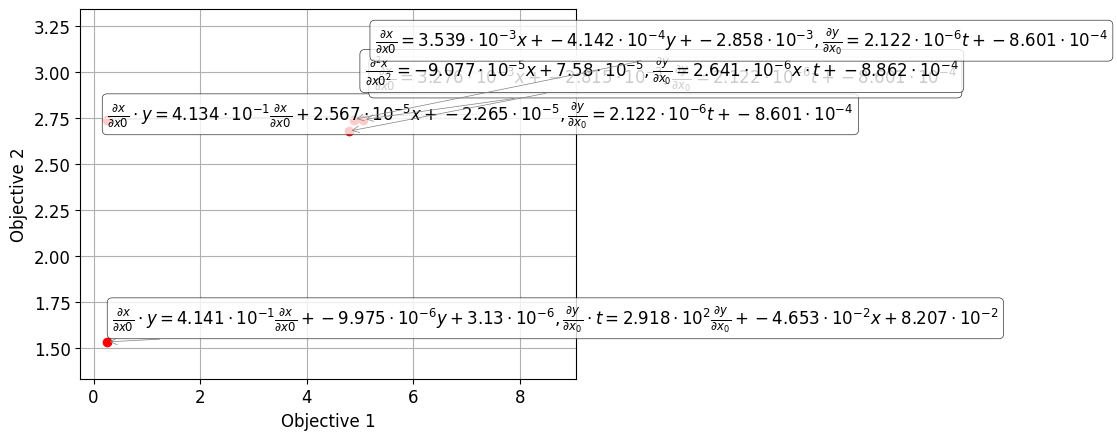


System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x177f0ad50>, <epde.structure.main_structures.SoEq object at 0x176f5f8d0>, <epde.structure.main_structures.SoEq object at 0x3186cb8d0>, <epde.structure.main_structures.SoEq object at 0x1749e09d0>, <epde.structure.main_structures.SoEq object at 0x15b916f50>]
EQ 2:
Saved: output/robot_78/system_force_41.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32f932a90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32f932a90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 2 1 2 1 1]
No sin data in cache!
No cos data in cache!
No 

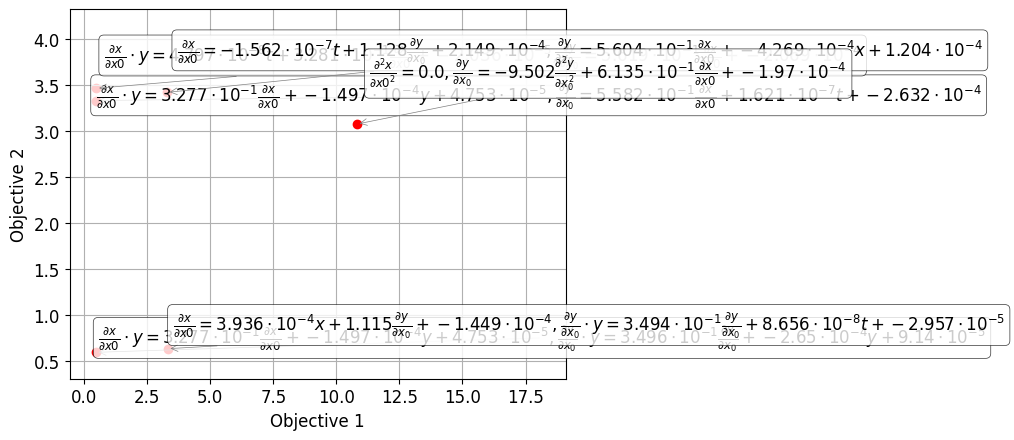


System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31876f3d0>, <epde.structure.main_structures.SoEq object at 0x31a9fa890>, <epde.structure.main_structures.SoEq object at 0x175736110>, <epde.structure.main_structures.SoEq object at 0x319f84310>, <epde.structure.main_structures.SoEq object at 0x31896b790>, <epde.structure.main_structures.SoEq object at 0x31a710b10>]
Saved: output/robot_78/system_force_42.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31aa80bd0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31aa80bd0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 

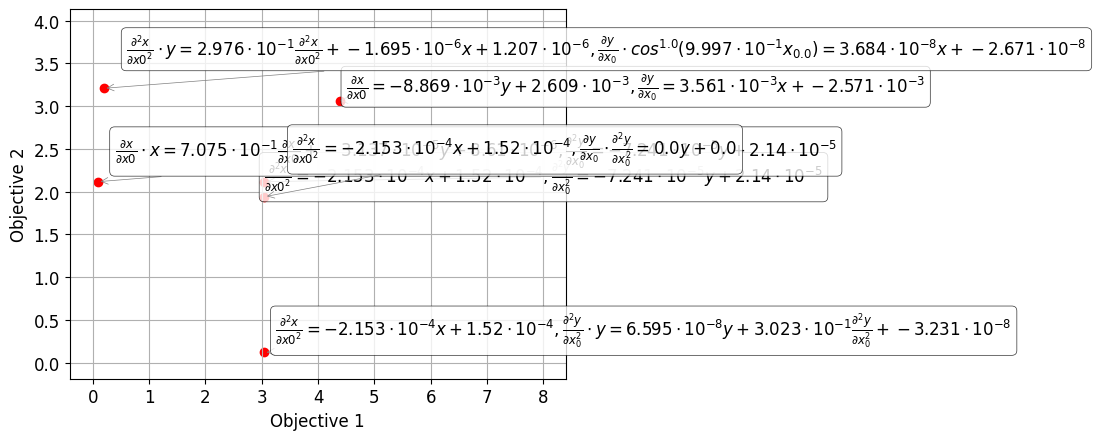


System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31b0bb2d0>, <epde.structure.main_structures.SoEq object at 0x318d79d50>, <epde.structure.main_structures.SoEq object at 0x319ec94d0>, <epde.structure.main_structures.SoEq object at 0x3192e9b90>, <epde.structure.main_structures.SoEq object at 0x319d73410>, <epde.structure.main_structures.SoEq object at 0x31a266890>]
Saved: output/robot_78/system_force_43.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3186a8f50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3186a8f50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1

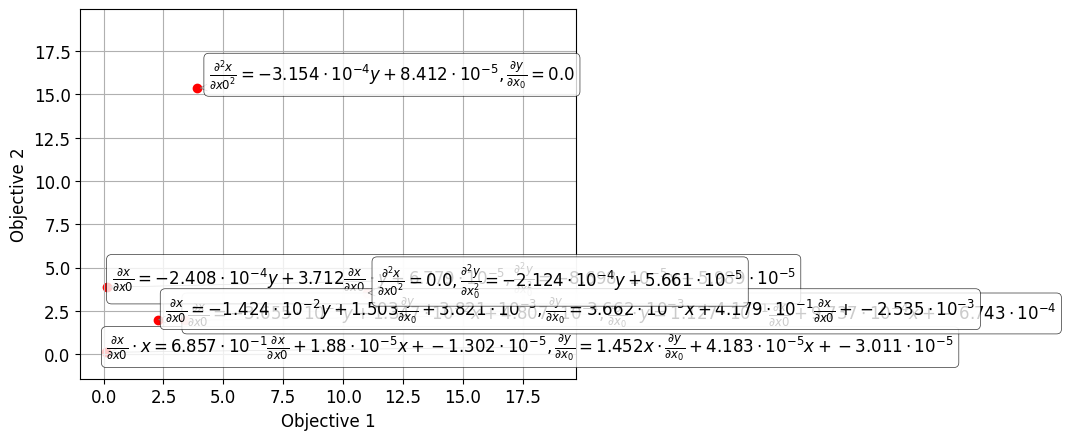


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x319f65f90>, <epde.structure.main_structures.SoEq object at 0x3189a25d0>, <epde.structure.main_structures.SoEq object at 0x319ca2310>, <epde.structure.main_structures.SoEq object at 0x31aba3190>, <epde.structure.main_structures.SoEq object at 0x32c474750>, <epde.structure.main_structures.SoEq object at 0x318998ad0>]
Saved: output/robot_78/system_force_44.csv































 Processing robot 79 with 4 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15b92de10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15b92de10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of de

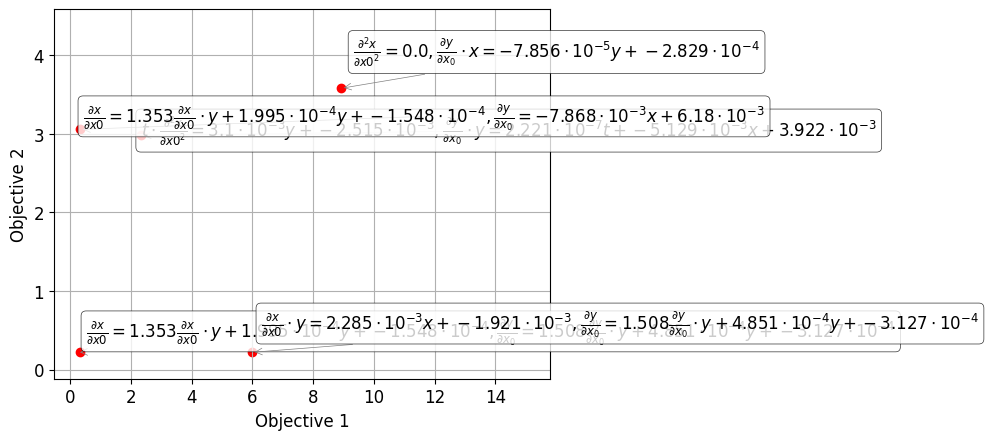


System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e637a50>, <epde.structure.main_structures.SoEq object at 0x31b52e4d0>, <epde.structure.main_structures.SoEq object at 0x15c5e4dd0>, <epde.structure.main_structures.SoEq object at 0x175dd3e50>, <epde.structure.main_structures.SoEq object at 0x172e5c690>]
EQ 2:
Saved: output/robot_79/system_force_41.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15b993d90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15b993d90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 2 1 2 1 1]
No sin data in cache!
No cos data in cache!
No 

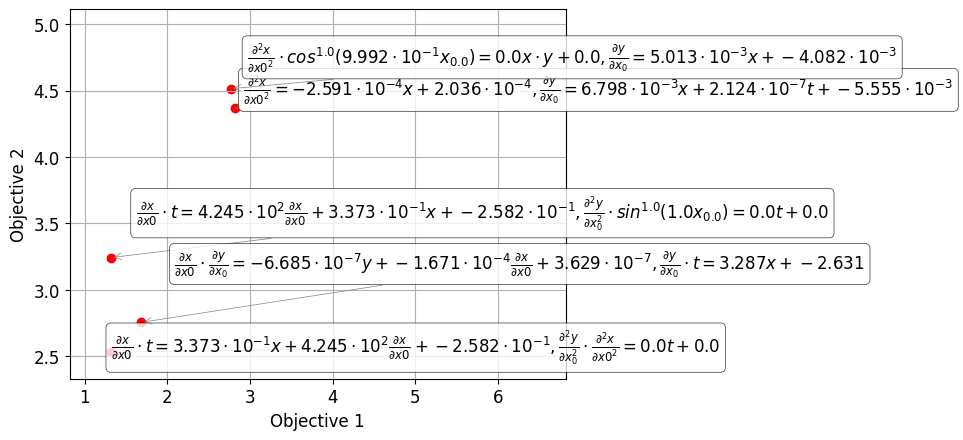


System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31b8cc3d0>, <epde.structure.main_structures.SoEq object at 0x175ded490>, <epde.structure.main_structures.SoEq object at 0x31b7dda90>, <epde.structure.main_structures.SoEq object at 0x15da2f010>, <epde.structure.main_structures.SoEq object at 0x31b7b9c90>]
EQ 2:
Saved: output/robot_79/system_force_42.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31b6d3350>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31b6d3350>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 2 1 2 1 1]
No sin data in cache!
No cos data in cache!


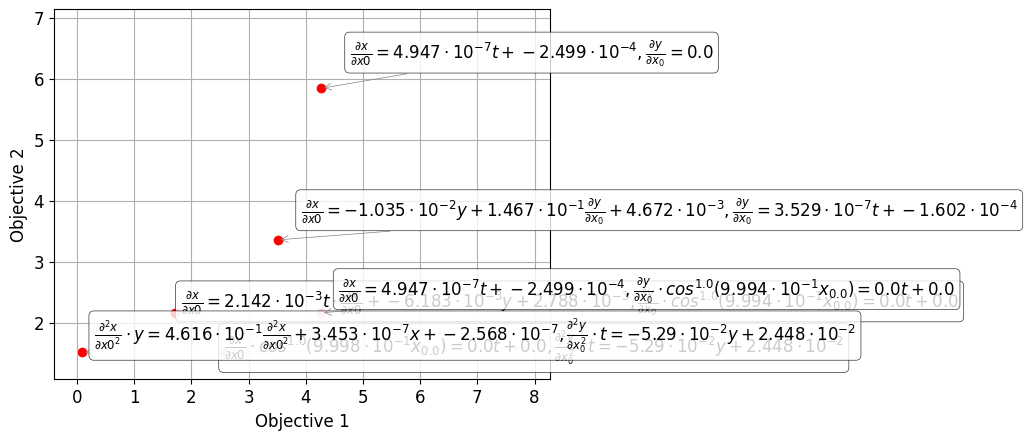


System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31b9c3490>, <epde.structure.main_structures.SoEq object at 0x31bc7d490>, <epde.structure.main_structures.SoEq object at 0x31b96c210>, <epde.structure.main_structures.SoEq object at 0x31b8afd10>, <epde.structure.main_structures.SoEq object at 0x31bb428d0>, <epde.structure.main_structures.SoEq object at 0x31ba29610>]
Saved: output/robot_79/system_force_43.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31ba4c510>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31ba4c510>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1

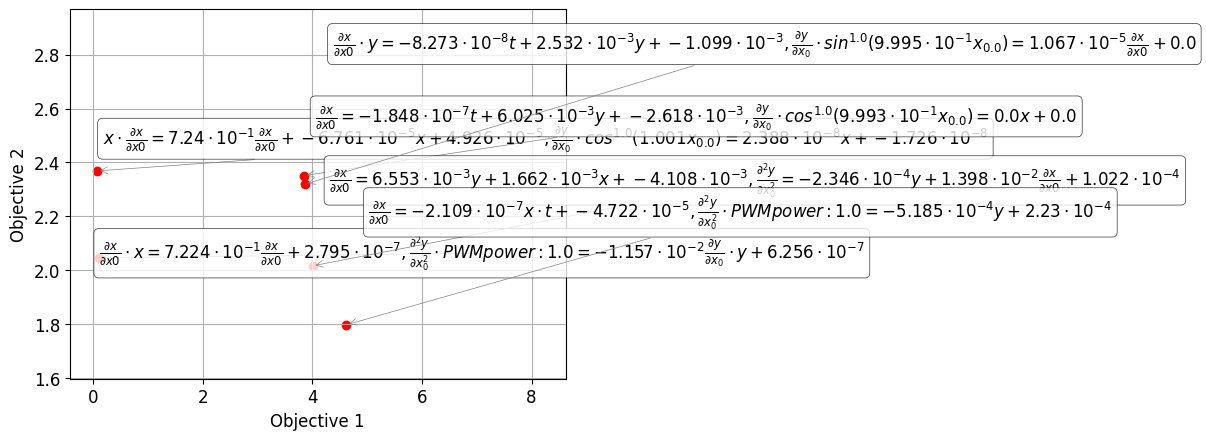


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32dddffd0>, <epde.structure.main_structures.SoEq object at 0x31bd50290>, <epde.structure.main_structures.SoEq object at 0x31b55c8d0>, <epde.structure.main_structures.SoEq object at 0x175e149d0>, <epde.structure.main_structures.SoEq object at 0x15d70aa90>, <epde.structure.main_structures.SoEq object at 0x15d75f110>]
Saved: output/robot_79/system_force_44.csv































 Processing robot 83 with 4 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15b994910>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15b994910>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of de

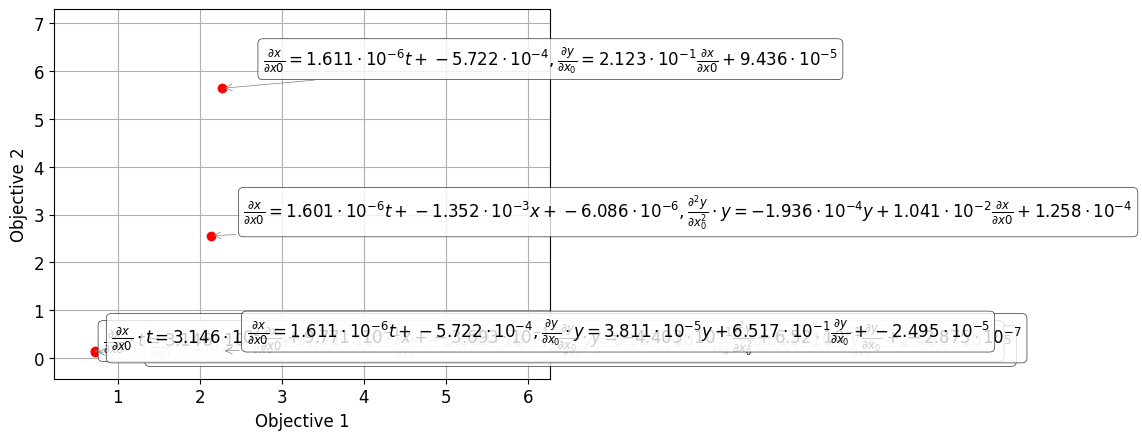


System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32dd5ff90>, <epde.structure.main_structures.SoEq object at 0x15fcb08d0>, <epde.structure.main_structures.SoEq object at 0x175dc4f90>, <epde.structure.main_structures.SoEq object at 0x15b971290>, <epde.structure.main_structures.SoEq object at 0x175e24d50>, <epde.structure.main_structures.SoEq object at 0x15d706450>]
Saved: output/robot_83/system_force_41.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15b9ea310>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15b9ea310>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 2 1

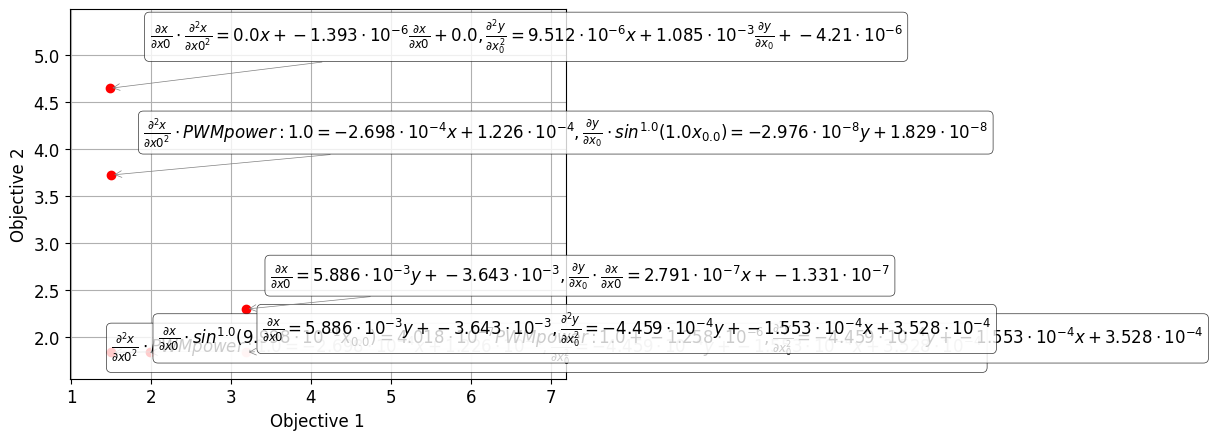


System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31b968350>, <epde.structure.main_structures.SoEq object at 0x15d74ed50>, <epde.structure.main_structures.SoEq object at 0x175e573d0>, <epde.structure.main_structures.SoEq object at 0x31ba73a90>, <epde.structure.main_structures.SoEq object at 0x17175c3d0>, <epde.structure.main_structures.SoEq object at 0x31b9caf50>]
Saved: output/robot_83/system_force_42.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15d760a10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15d760a10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 

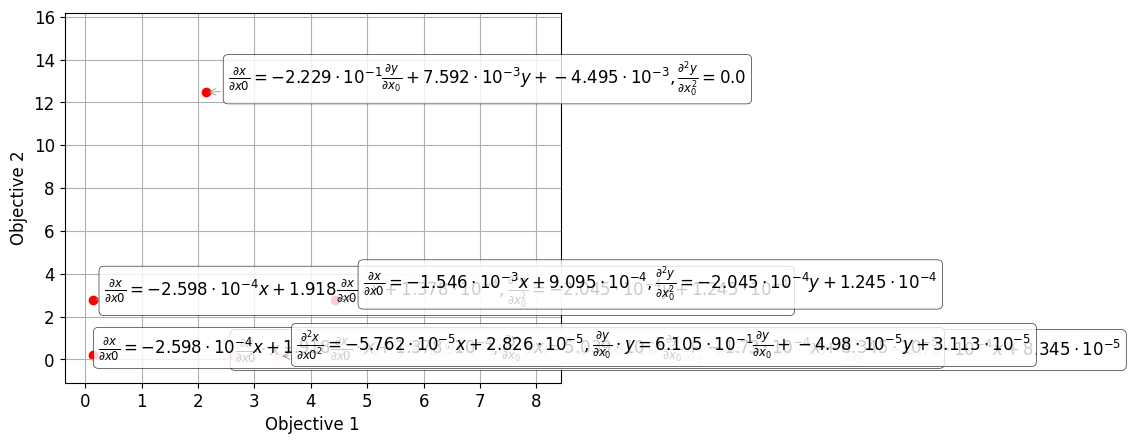


System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31b86ac50>, <epde.structure.main_structures.SoEq object at 0x172ecf3d0>, <epde.structure.main_structures.SoEq object at 0x31b5c69d0>, <epde.structure.main_structures.SoEq object at 0x31b8b0050>, <epde.structure.main_structures.SoEq object at 0x31bdad050>, <epde.structure.main_structures.SoEq object at 0x32dd66950>]
Saved: output/robot_83/system_force_43.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31bd1f8d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31bd1f8d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1

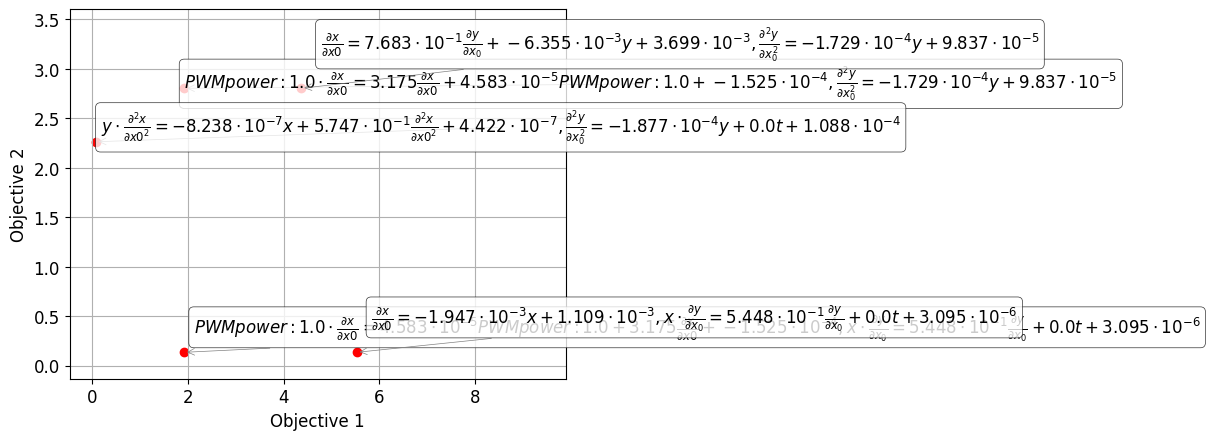


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31b5e4f90>, <epde.structure.main_structures.SoEq object at 0x31b5a6f10>, <epde.structure.main_structures.SoEq object at 0x31bae7d90>, <epde.structure.main_structures.SoEq object at 0x1777369d0>, <epde.structure.main_structures.SoEq object at 0x31b9acf50>]
EQ 2:
Saved: output/robot_83/system_force_44.csv































 Processing robot 31 with 4 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x176cd2e50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x176cd2e50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the poo

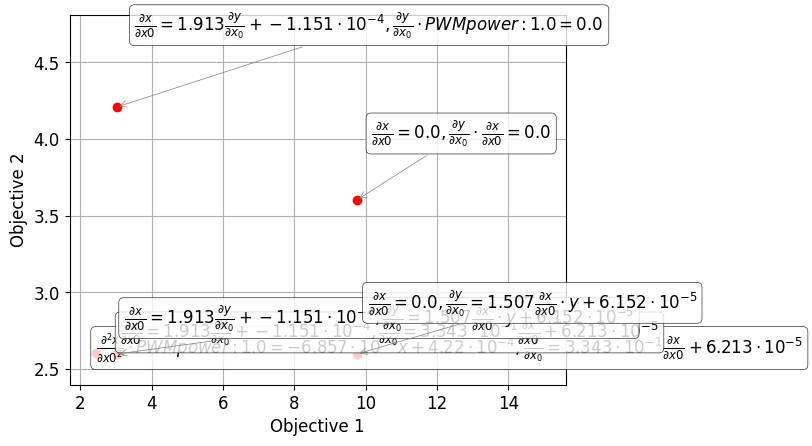


System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x176ce0050>, <epde.structure.main_structures.SoEq object at 0x15f3aa2d0>, <epde.structure.main_structures.SoEq object at 0x14f7e3b50>, <epde.structure.main_structures.SoEq object at 0x1731db910>, <epde.structure.main_structures.SoEq object at 0x172f7a310>, <epde.structure.main_structures.SoEq object at 0x172ff73d0>]
Saved: output/robot_31/system_force_41.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x176cdc990>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x176cdc990>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 2 1

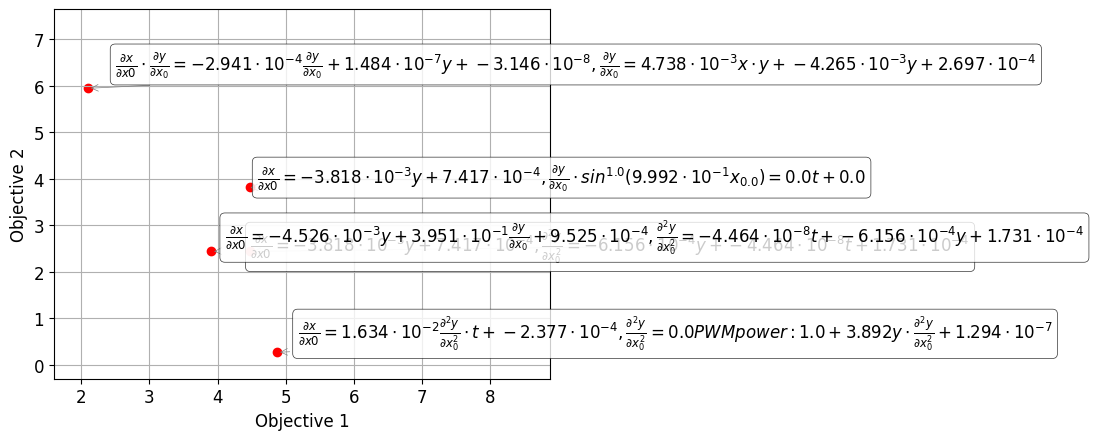


System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x16a0ed490>, <epde.structure.main_structures.SoEq object at 0x176d6f350>, <epde.structure.main_structures.SoEq object at 0x14fc1fbd0>, <epde.structure.main_structures.SoEq object at 0x169394910>, <epde.structure.main_structures.SoEq object at 0x158479b90>]
EQ 2:
Saved: output/robot_31/system_force_42.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x16970a250>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x16970a250>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 2 1 2 1 1]
No sin data in cache!
No cos data in cache!


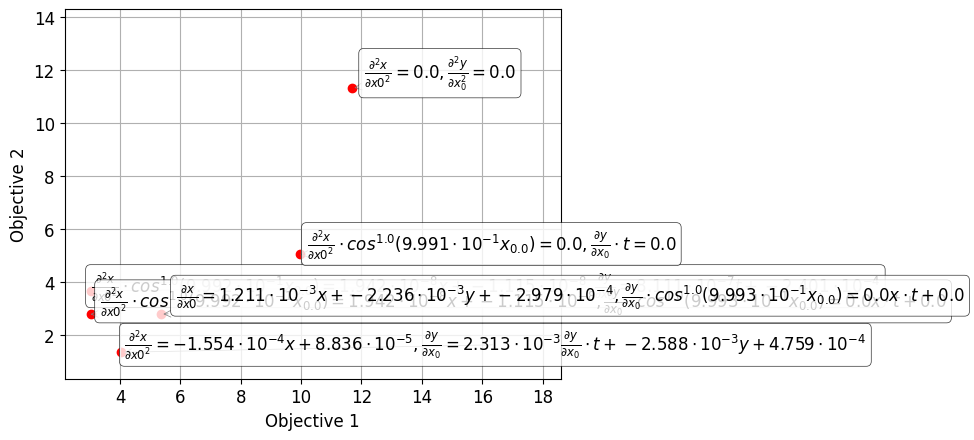


System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x1584d4150>, <epde.structure.main_structures.SoEq object at 0x14fe7e250>, <epde.structure.main_structures.SoEq object at 0x176cf7e90>, <epde.structure.main_structures.SoEq object at 0x16a0cb590>, <epde.structure.main_structures.SoEq object at 0x14f948d10>, <epde.structure.main_structures.SoEq object at 0x14fd4b350>]
Saved: output/robot_31/system_force_43.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x17700a6d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x17700a6d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1

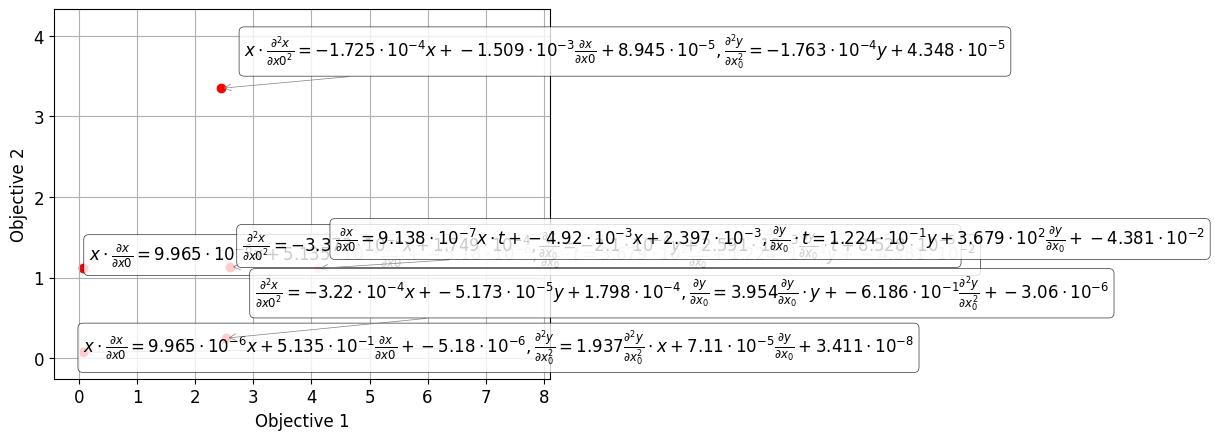


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x16a0d5f10>, <epde.structure.main_structures.SoEq object at 0x14fe7cb90>, <epde.structure.main_structures.SoEq object at 0x14fda29d0>, <epde.structure.main_structures.SoEq object at 0x14f96b750>, <epde.structure.main_structures.SoEq object at 0x14fd25490>, <epde.structure.main_structures.SoEq object at 0x15fe6f450>]
Saved: output/robot_31/system_force_44.csv































 Processing robot 32 with 4 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3404de4d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3404de4d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of de

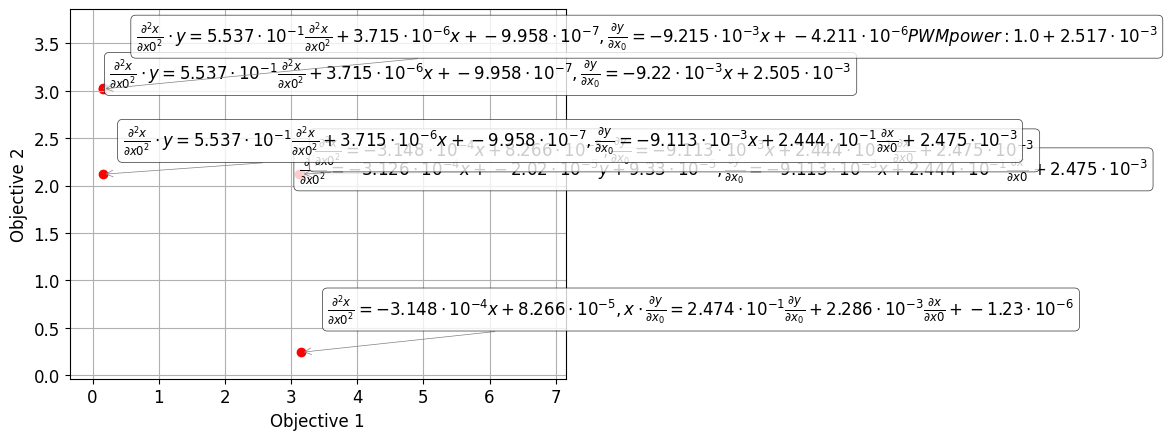


System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x340aa5dd0>, <epde.structure.main_structures.SoEq object at 0x340958a90>, <epde.structure.main_structures.SoEq object at 0x340ad7510>, <epde.structure.main_structures.SoEq object at 0x3405e24d0>, <epde.structure.main_structures.SoEq object at 0x3404c19d0>, <epde.structure.main_structures.SoEq object at 0x3409fd090>]
Saved: output/robot_32/system_force_41.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3404f92d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3404f92d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 2 1

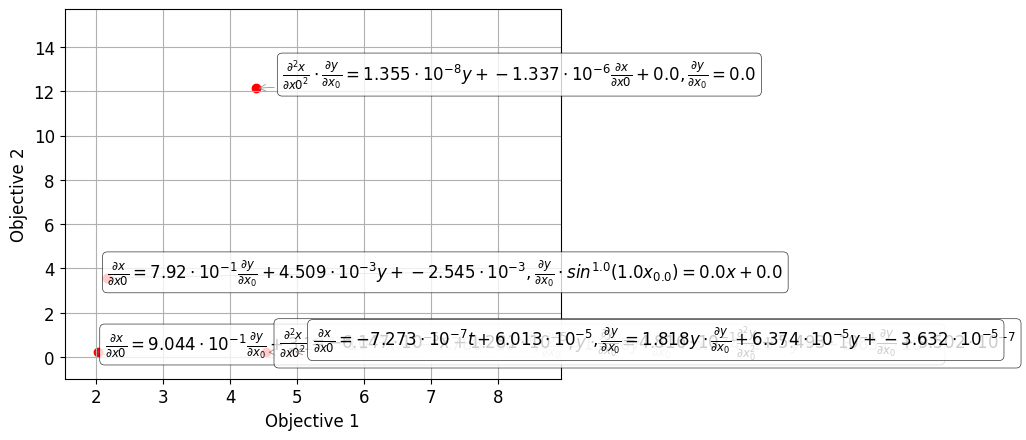


System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x15b6e7c50>, <epde.structure.main_structures.SoEq object at 0x15be66f10>, <epde.structure.main_structures.SoEq object at 0x15bb97890>, <epde.structure.main_structures.SoEq object at 0x15be0c650>, <epde.structure.main_structures.SoEq object at 0x15b8971d0>]
EQ 2:
Saved: output/robot_32/system_force_42.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15e9bb4d0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15e9bb4d0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 2 1 2 1 1]
No sin data in cache!
No cos data in cache!


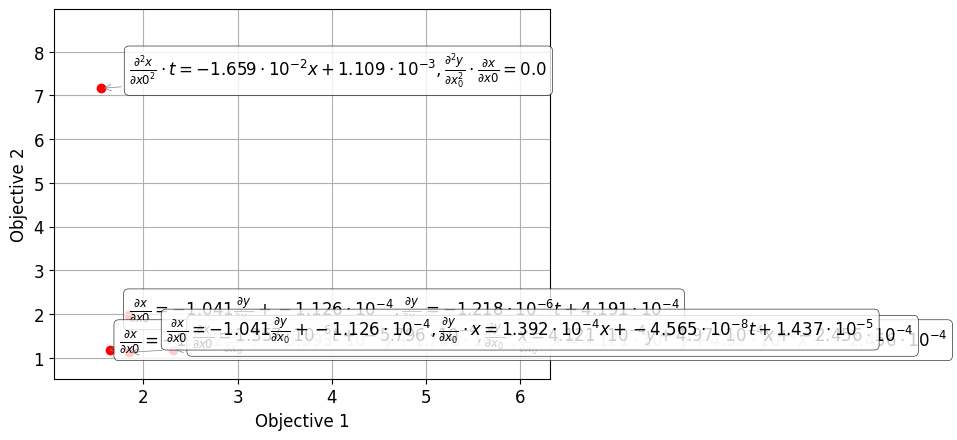


System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x15c27ab10>, <epde.structure.main_structures.SoEq object at 0x15b6878d0>, <epde.structure.main_structures.SoEq object at 0x15bd7e350>, <epde.structure.main_structures.SoEq object at 0x15ee69610>, <epde.structure.main_structures.SoEq object at 0x15be8ae90>]
EQ 2:
Saved: output/robot_32/system_force_43.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3407f6990>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x3407f6990>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 2 1 2 1 1]
No sin data in cache!
No cos data in cache!

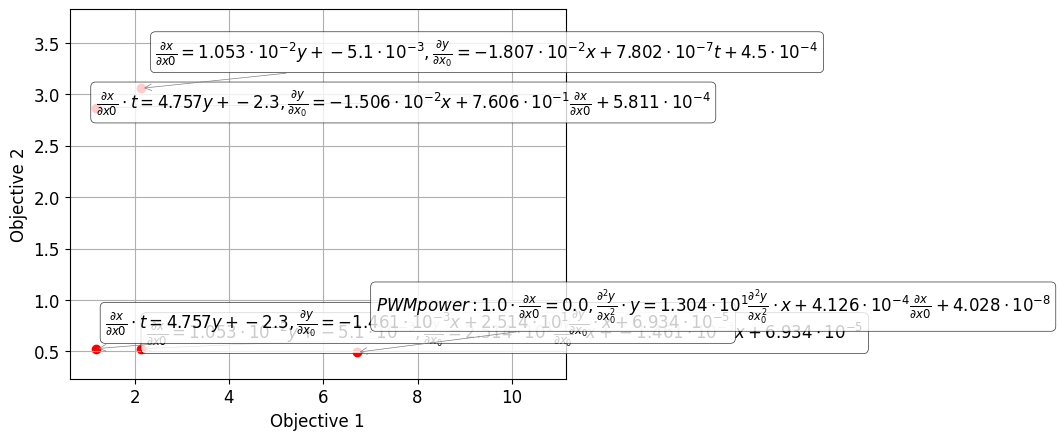


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x15dac3bd0>, <epde.structure.main_structures.SoEq object at 0x340aa2e10>, <epde.structure.main_structures.SoEq object at 0x340535890>, <epde.structure.main_structures.SoEq object at 0x15c25dc90>, <epde.structure.main_structures.SoEq object at 0x15ee99790>]
EQ 2:
Saved: output/robot_32/system_force_44.csv































 Processing robot 34 with 4 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x172ef2e50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x172ef2e50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the poo

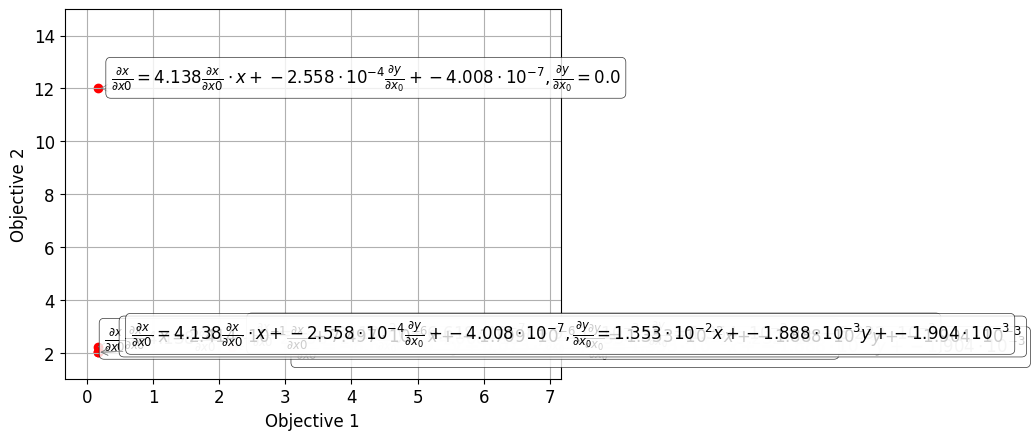


System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x1731df3d0>, <epde.structure.main_structures.SoEq object at 0x15f3168d0>, <epde.structure.main_structures.SoEq object at 0x159395010>, <epde.structure.main_structures.SoEq object at 0x15b377850>, <epde.structure.main_structures.SoEq object at 0x15b3cd1d0>, <epde.structure.main_structures.SoEq object at 0x15b348510>]
Saved: output/robot_34/system_force_41.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x172ec0190>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x172ec0190>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 2 1

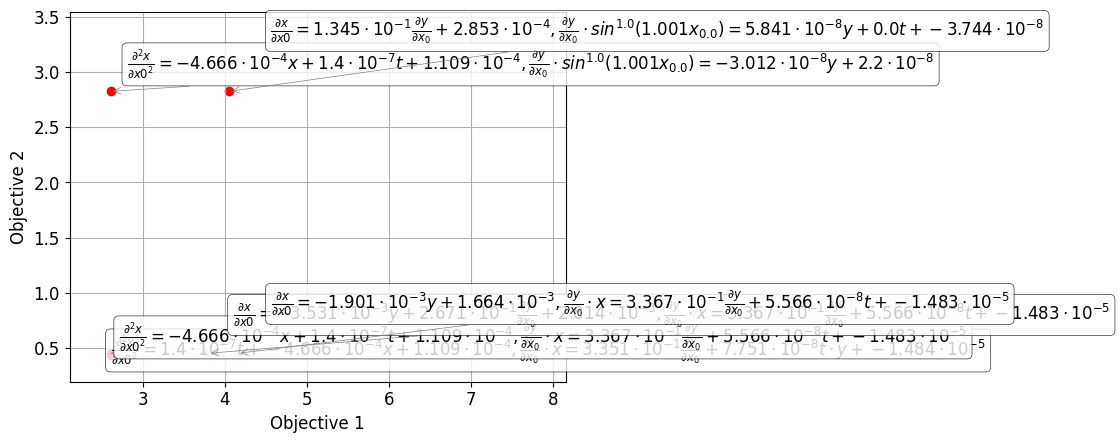


System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x15b31bfd0>, <epde.structure.main_structures.SoEq object at 0x158437dd0>, <epde.structure.main_structures.SoEq object at 0x14fcb9d90>, <epde.structure.main_structures.SoEq object at 0x14f94b2d0>, <epde.structure.main_structures.SoEq object at 0x159c4ed50>, <epde.structure.main_structures.SoEq object at 0x15f3b05d0>]
Saved: output/robot_34/system_force_42.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x14fedd690>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x14fedd690>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 

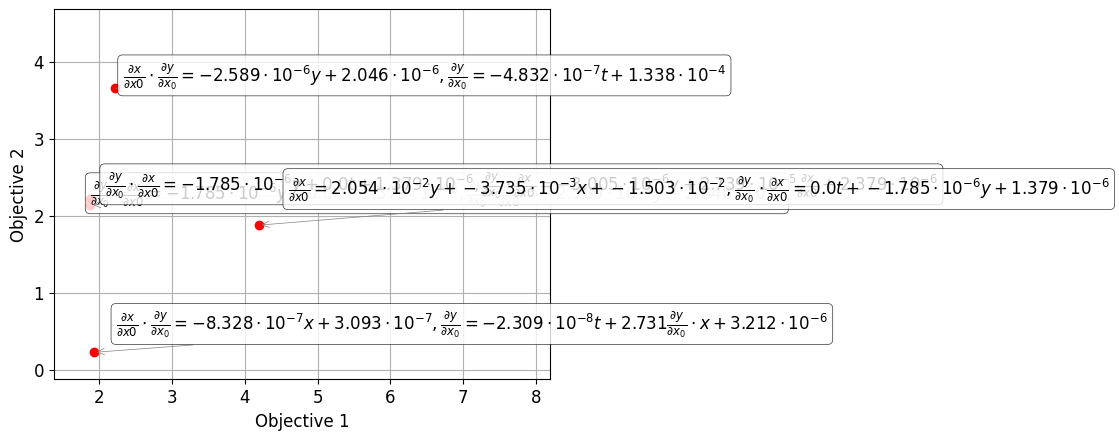


System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x16973be90>, <epde.structure.main_structures.SoEq object at 0x17320fa90>, <epde.structure.main_structures.SoEq object at 0x15847b7d0>, <epde.structure.main_structures.SoEq object at 0x1593e8cd0>, <epde.structure.main_structures.SoEq object at 0x173258090>]
EQ 2:
Saved: output/robot_34/system_force_43.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x16a046b10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x16a046b10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 1 2 1]
Among them, the pool contains [1 2 1 2 1 1]
No sin data in cache!
No cos data in cache!

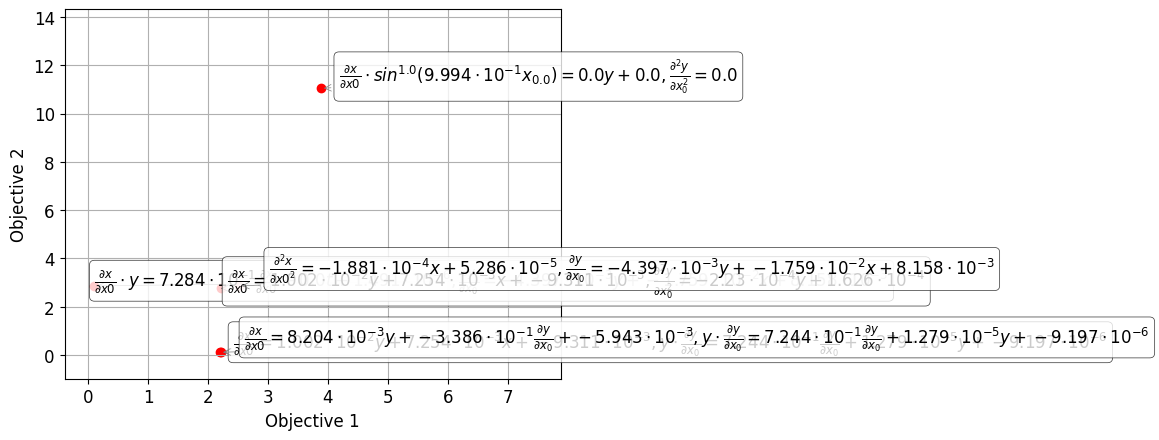


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x15937f790>, <epde.structure.main_structures.SoEq object at 0x159350510>, <epde.structure.main_structures.SoEq object at 0x1593db550>, <epde.structure.main_structures.SoEq object at 0x15fefc050>, <epde.structure.main_structures.SoEq object at 0x15b2a6bd0>, <epde.structure.main_structures.SoEq object at 0x14fc55590>]
Saved: output/robot_34/system_force_44.csv


In [ ]:
# ====================
# --- MAIN PIPELINE ---
# ====================
def process_robot(object_id, normalized_coord_data,pwm_signal, num_parts=1, output_dir=Path("output")):
    """PROCESS ONE ROBOT AND SPLIT INTO PARTS"""
    print(f"\n Processing robot {object_id} with {num_parts} parts...")

    # === Create directories ===
    robot_dir = output_dir / f"robot_{object_id}"
    robot_dir.mkdir(parents=True, exist_ok=True)

    points = np.array(normalized_coord_data[object_id])
    cut_number = min(2750, len(points))
    cut_points = points[:cut_number]

    part_size = cut_number // num_parts
    boundaries = [i * part_size for i in range(num_parts)] + [cut_number]

    for part_idx in range(num_parts):
        start_idx = boundaries[part_idx]
        end_idx = boundaries[part_idx + 1]
        part_points = cut_points[start_idx:end_idx]
        pwm_part = np.array(pwm_signal[start_idx:end_idx])
        t_data = np.arange(len(part_points))
        x_data, y_data = part_points[:, 0], part_points[:, 1]


        equation_processor = EquationProcessor()
        variable_names = ['x', 'y']

        epde_search_obj_system = EpdeSearch(
            use_solver=False,
            boundary=3, # boundary >= polynomial_window // 2
            preprocessor_kwargs={'polynomial_window': 7},
            coordinate_tensors=[t_data]
        )

        epde_search_obj_system.set_moeadd_params(
            population_size=6,
            training_epochs=50
        )
        
        epde_search_obj_system.set_preprocessor(
            default_preprocessor_type='poly',
            preprocessor_kwargs={'use_smoothing': True,
                                    'sigma': 50}
        )

        
        external_force_token = CacheStoredTokens(
            token_type='ext_force',
            token_labels=['PWM'],
            token_tensors={'PWM': pwm_part},
            params_ranges={'power': (1, 1)},
            params_equality_ranges = None,
            meaningful=True
        )
        '''
        pwm_derivs_token = ExternalDerivativesTokens(
            'PWM_derivs',                     # имя токена
            boundary=4,                       # как и у других данных
            time_axis=0,                      # ось времени (0, т.к. одномерная зависимость)
            base_token_label='PWM',           # имя базового токена
            token_tensor=pwm_signal,          # сам сигнал
            max_orders=2,                     # до какой производной считать (1 -> dPWM/dt, 2 -> d²PWM/dt²)
            deriv_method='poly',              # метод вычисления производных
            deriv_method_kwargs={
                'smooth': True,
                'grid': [t_data]
            },
            params_ranges={'power': (1, 1)},  # оставляем без возведения в степень
            params_equality_ranges=None,
            meaningful=True
        )
        '''
        equation_system = EquationDiscoverer([x_data, y_data])
        part_equations = equation_system.discover_system_equation(
            epde_search_obj_system,
            additional_tokens=[external_force_token],
            dimensionality=0
        )

        
        equation_per_level = [
            [[str(eq) for eq in solution.vals] for solution in level] 
            for level in part_equations
        ]
        print(equation_per_level)

        values_per_level = [
        [solution.obj_fun for solution in level]
                            for level in part_equations]
        for level_idx, level in enumerate(values_per_level):
            print(f"Level {level_idx}:")
            for sol_idx, obj_values in enumerate(level):
                print(f"Solution {sol_idx}: {obj_values}")


        # Выводим для проверки
        for level_idx, level in enumerate(equation_per_level):
            print(f"Level {level_idx}:")
            for sol_idx, eq_list in enumerate(level):
                print(f"  Solution {sol_idx}:")
                for eq_str in eq_list:
                    print(f"    {eq_str}")


        fig = plt.figure() 
        epde_search_obj_system.visualize_solutions(dimensions=[0,1])
        plt.show()



        # PREPROCESSING
        table_main = [{i: [{}, {}]} for i in variable_names]
        k = 0

        vals_flat = []
        for elem in part_equations:
            vals_flat.extend(elem)

        table_main, k = equation_processor.object_table(
            [vals_flat], variable_names, table_main, k, ''
        )

        print(f"\nSystem of DE {part_idx + 1} (startpoint {start_idx}-{end_idx - 1}):")
        for i, eq in enumerate(part_equations):
            print(f"EQ {i + 1}:")
            print(eq)

        # SAVE TABLE

        frame_main = equation_processor.preprocessing_table(variable_names, table_main, k)
        output_path = robot_dir / f"system_force_{num_parts}{part_idx + 1}.csv"
        frame_main.to_csv(output_path, sep=',', encoding='utf-8')
        print(f"Saved: {output_path}")



# ==========================
# --- DISTANCE CALCULATOR ---
# ==========================
def find_closest_robots(normalized_coord_data, target_id, n_closest=2):
    """FIND NEAREST ROBOTS TO TARGET"""
    target_coord = normalized_coord_data[target_id][0]
    distances = {
        rid: np.linalg.norm(np.array(coords[0]) - target_coord)
        for rid, coords in normalized_coord_data.items() if rid != target_id
    }
    closest = sorted(distances, key=distances.get)[:n_closest]
    print(f"\n Closest to {target_id}: {closest}")
    return closest


# =====================
# --- MAIN FUNCTION ---
# =====================
def main(target_robot=78, num_parts=2, n_closest=2):
    with open('data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle', 'rb') as file:
        raw_data = pickle.load(file)

    processor = DataProcessor(raw_data)
    processor.extract_data()
    pwm_signal = np.array(processor.angle_data[target_robot])
    normalized_coord_data = processor.normalize_all_coordinates()
    robots_to_process = [target_robot]
    if n_closest>0:
    # Найти ближайших роботов
        closest = find_closest_robots(normalized_coord_data, target_robot, n_closest)
        robots_to_process += closest

    output_dir = Path("output")
    for rid in robots_to_process:
        process_robot(rid, normalized_coord_data, pwm_signal,num_parts=num_parts, output_dir=output_dir)


if __name__ == "__main__":
    for i in [78, 79,  83, 31, 32 , 34]:
        main(target_robot=i, num_parts=4, n_closest=0)

































 Processing robot 78 with 4 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x1717a0090>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x1717a0090>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data in cache!
self.vars_demand_equation {'y', 'x'}
Creating new equation, sparsity value [3.43217304e-07 1.68197361e-06]
New solution accepted, confirmed 1/6 solutions.
Creating new equation, sparsity value [4.15766914e-06 3.40061208e-10]
New solution accepted, confirmed 2/6 solutions.
Creating new equation, sparsity value [0.01

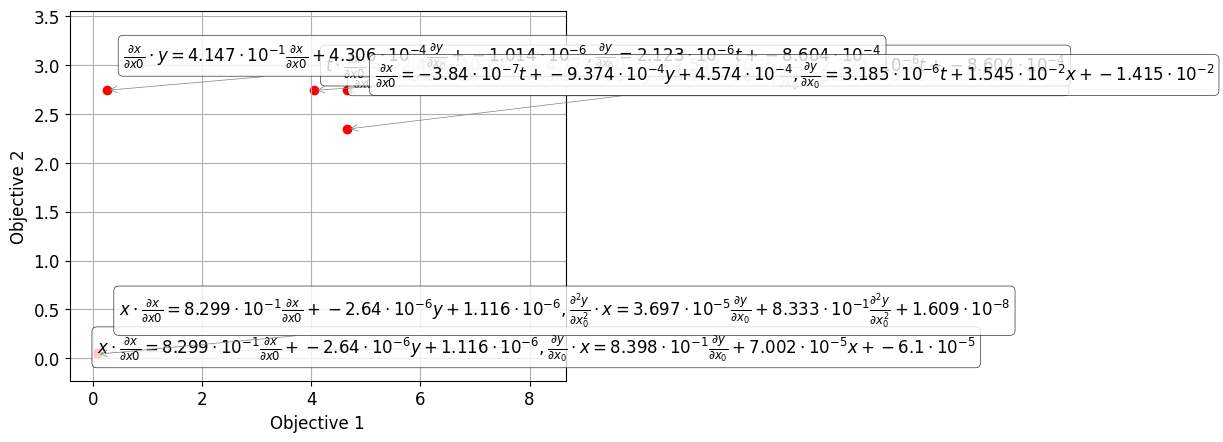


System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31b673b50>, <epde.structure.main_structures.SoEq object at 0x15d78f3d0>, <epde.structure.main_structures.SoEq object at 0x31b6e4910>, <epde.structure.main_structures.SoEq object at 0x31a939750>, <epde.structure.main_structures.SoEq object at 0x31b833b90>, <epde.structure.main_structures.SoEq object at 0x31b740650>]
Saved: output/robot_78/system_41.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32dd6a890>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32dd6a890>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No

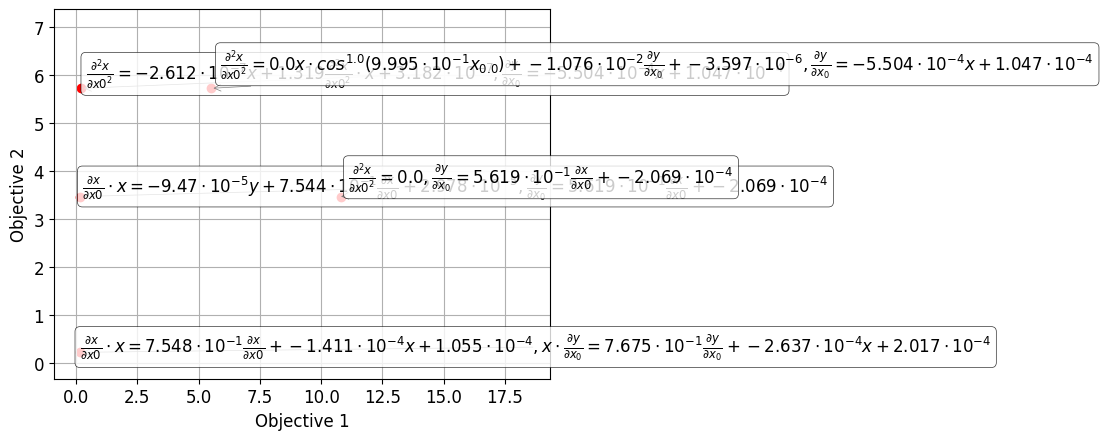


System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31b980bd0>, <epde.structure.main_structures.SoEq object at 0x31b9e1590>, <epde.structure.main_structures.SoEq object at 0x31b959e50>, <epde.structure.main_structures.SoEq object at 0x31bbc3dd0>, <epde.structure.main_structures.SoEq object at 0x31bb3ead0>]
EQ 2:
Saved: output/robot_78/system_42.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31bac9810>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31bac9810>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data 

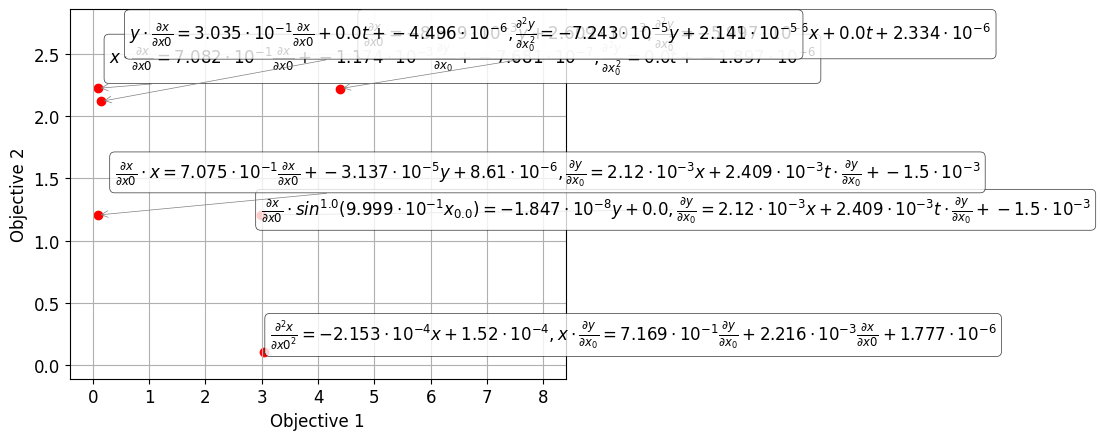


System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x31bb68f10>, <epde.structure.main_structures.SoEq object at 0x31b8b84d0>, <epde.structure.main_structures.SoEq object at 0x31b5c8cd0>, <epde.structure.main_structures.SoEq object at 0x31b5be750>, <epde.structure.main_structures.SoEq object at 0x31b9f8090>, <epde.structure.main_structures.SoEq object at 0x31b97ec90>]
Saved: output/robot_78/system_43.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31b5a2d90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x31b5a2d90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1

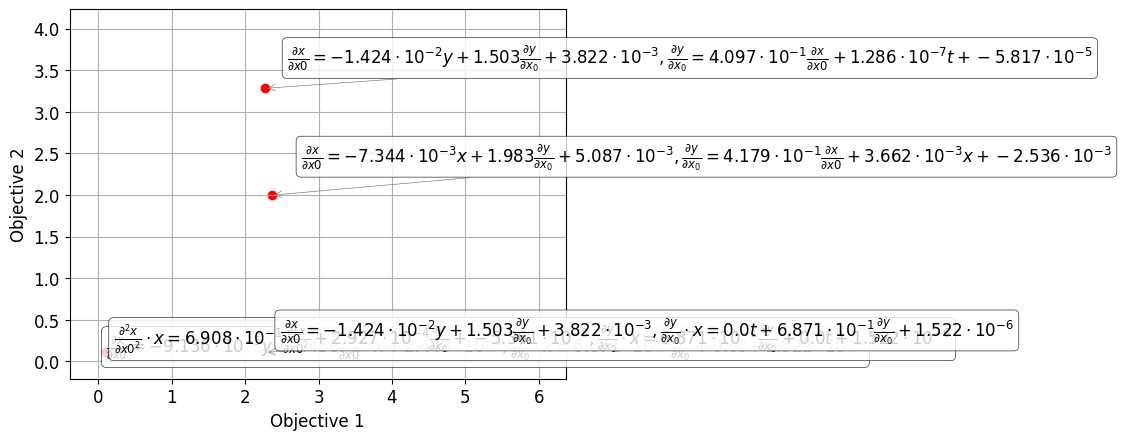


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32dd46050>, <epde.structure.main_structures.SoEq object at 0x31b6b73d0>, <epde.structure.main_structures.SoEq object at 0x32dd8f790>, <epde.structure.main_structures.SoEq object at 0x31b55e2d0>, <epde.structure.main_structures.SoEq object at 0x31b84d1d0>]
EQ 2:
Saved: output/robot_78/system_44.csv































 Processing robot 79 with 4 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x175da2050>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x175da2050>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contai

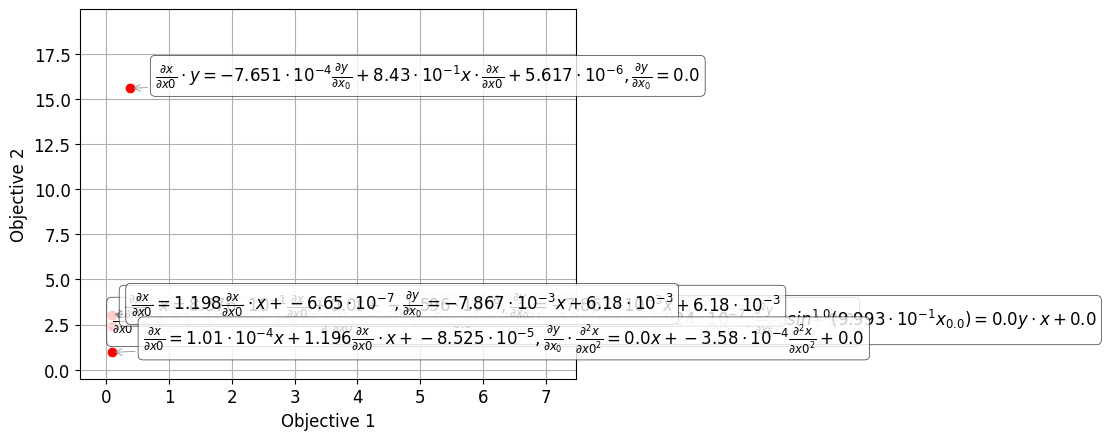


System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e0465d0>, <epde.structure.main_structures.SoEq object at 0x32e080150>, <epde.structure.main_structures.SoEq object at 0x32dfad250>, <epde.structure.main_structures.SoEq object at 0x32e11a390>, <epde.structure.main_structures.SoEq object at 0x32de87210>, <epde.structure.main_structures.SoEq object at 0x32e004750>]
Saved: output/robot_79/system_41.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x175d97110>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x175d97110>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No

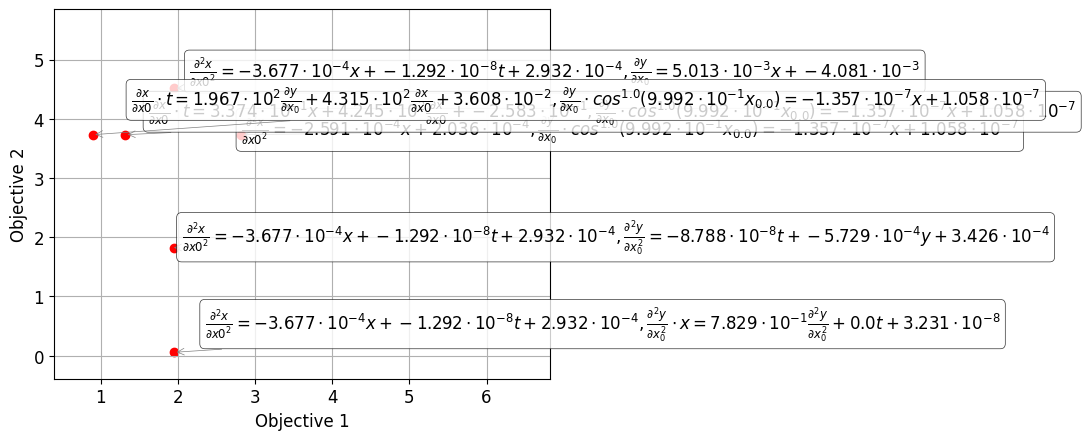


System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e129310>, <epde.structure.main_structures.SoEq object at 0x32e55ec50>, <epde.structure.main_structures.SoEq object at 0x32e1a95d0>, <epde.structure.main_structures.SoEq object at 0x32e425dd0>, <epde.structure.main_structures.SoEq object at 0x32df3f390>, <epde.structure.main_structures.SoEq object at 0x32e24ded0>]
Saved: output/robot_79/system_42.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e1f4290>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e1f4290>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]

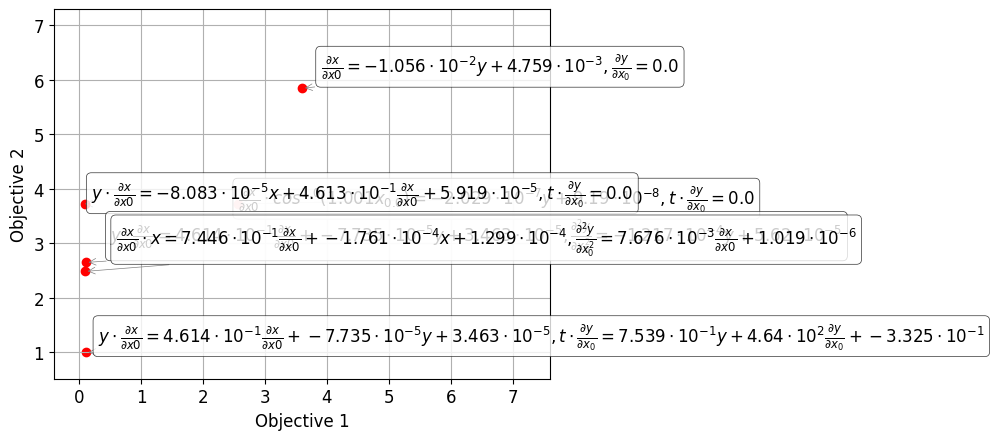


System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e36e810>, <epde.structure.main_structures.SoEq object at 0x32e5b9390>, <epde.structure.main_structures.SoEq object at 0x32e446c50>, <epde.structure.main_structures.SoEq object at 0x32e4f91d0>, <epde.structure.main_structures.SoEq object at 0x32e405190>, <epde.structure.main_structures.SoEq object at 0x32e24fb90>]
Saved: output/robot_79/system_43.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32dec7710>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32dec7710>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1

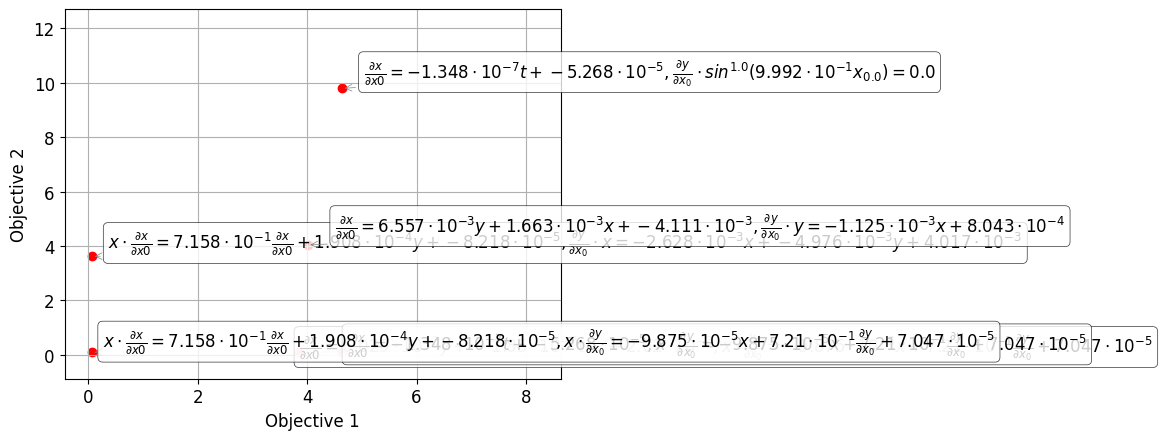


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e36c990>, <epde.structure.main_structures.SoEq object at 0x175da1f10>, <epde.structure.main_structures.SoEq object at 0x175daa990>, <epde.structure.main_structures.SoEq object at 0x175e65a90>, <epde.structure.main_structures.SoEq object at 0x32e5f2610>, <epde.structure.main_structures.SoEq object at 0x175d82dd0>]
Saved: output/robot_79/system_44.csv































 Processing robot 83 with 4 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32de4c710>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32de4c710>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined 

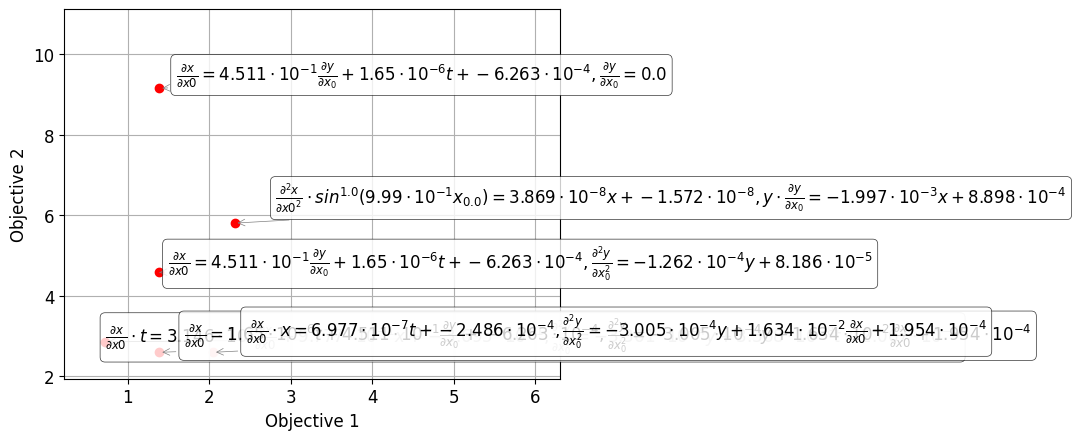


System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x15da93d10>, <epde.structure.main_structures.SoEq object at 0x32debf8d0>, <epde.structure.main_structures.SoEq object at 0x32dfac110>, <epde.structure.main_structures.SoEq object at 0x32dfd6750>, <epde.structure.main_structures.SoEq object at 0x15fc73a50>, <epde.structure.main_structures.SoEq object at 0x32df285d0>]
Saved: output/robot_83/system_41.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x1695c3690>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x1695c3690>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No

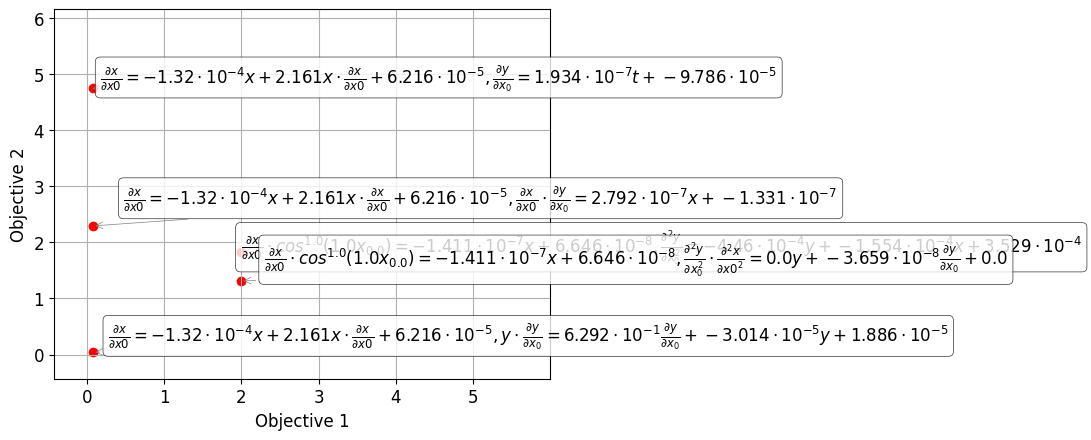


System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32de94190>, <epde.structure.main_structures.SoEq object at 0x32e076bd0>, <epde.structure.main_structures.SoEq object at 0x32e37fa10>, <epde.structure.main_structures.SoEq object at 0x32e1ab7d0>, <epde.structure.main_structures.SoEq object at 0x32e344810>]
EQ 2:
Saved: output/robot_83/system_42.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x168af4dd0>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x168af4dd0>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data 

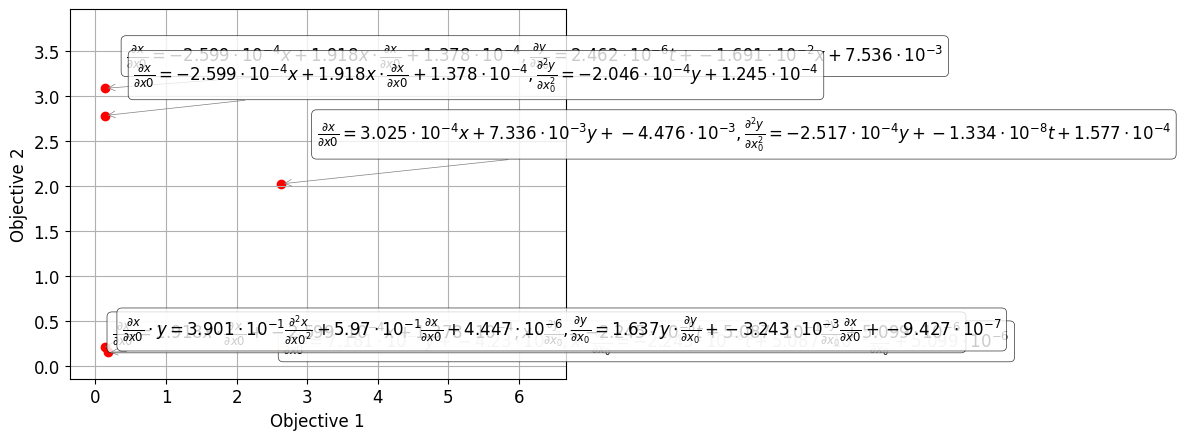


System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e046d10>, <epde.structure.main_structures.SoEq object at 0x32e55c490>, <epde.structure.main_structures.SoEq object at 0x32e0f11d0>, <epde.structure.main_structures.SoEq object at 0x32e4ffd90>, <epde.structure.main_structures.SoEq object at 0x32e447190>, <epde.structure.main_structures.SoEq object at 0x32e486090>]
Saved: output/robot_83/system_43.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e453350>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e453350>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1

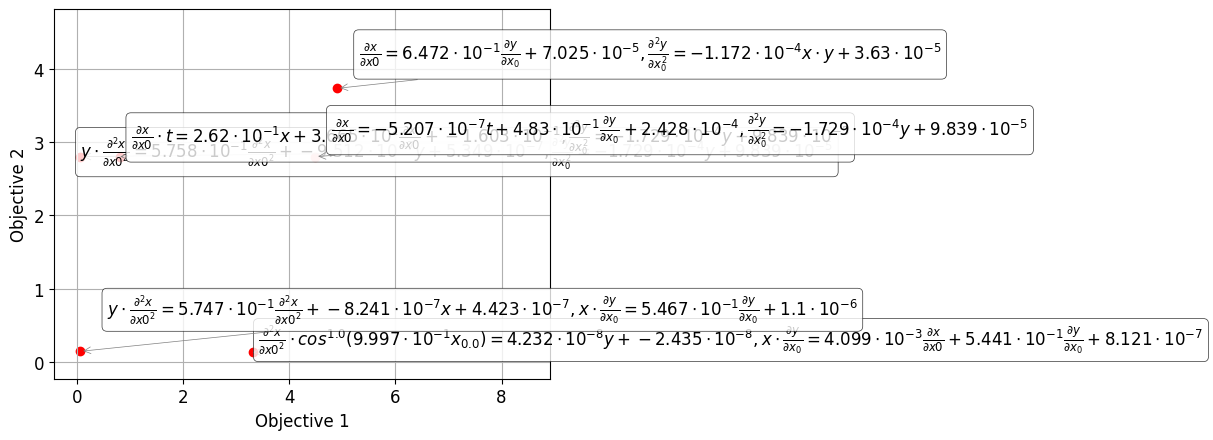


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e4755d0>, <epde.structure.main_structures.SoEq object at 0x32e2a34d0>, <epde.structure.main_structures.SoEq object at 0x32e3c0dd0>, <epde.structure.main_structures.SoEq object at 0x32e25bb90>, <epde.structure.main_structures.SoEq object at 0x32e556590>, <epde.structure.main_structures.SoEq object at 0x15fc77310>]
Saved: output/robot_83/system_44.csv































 Processing robot 31 with 4 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32de5de50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32de5de50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined 

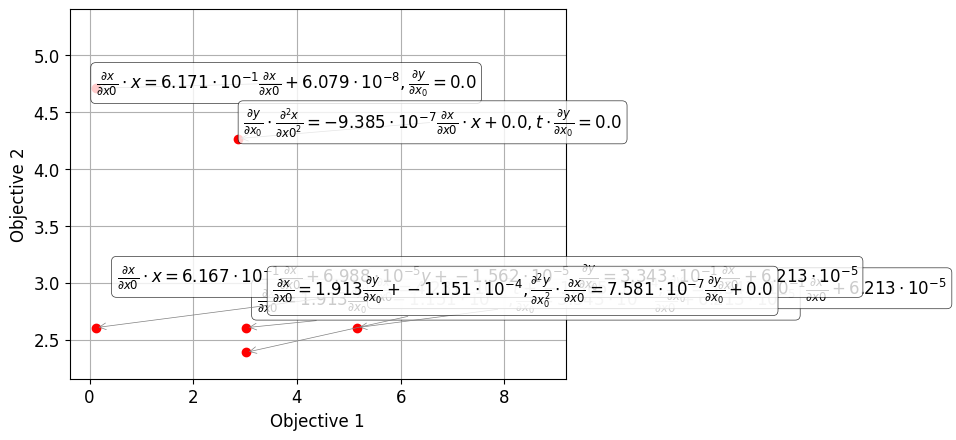


System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x15b95dd10>, <epde.structure.main_structures.SoEq object at 0x32e0b9b90>, <epde.structure.main_structures.SoEq object at 0x32e128710>, <epde.structure.main_structures.SoEq object at 0x32dfdfb10>, <epde.structure.main_structures.SoEq object at 0x32e14c790>, <epde.structure.main_structures.SoEq object at 0x32e0fc3d0>]
Saved: output/robot_31/system_41.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x168ed9350>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x168ed9350>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No

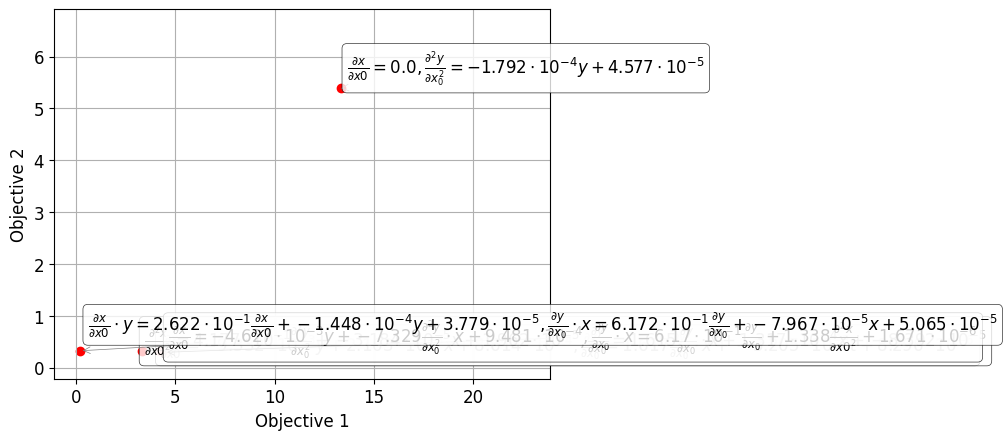


System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e3f7810>, <epde.structure.main_structures.SoEq object at 0x32e1f5410>, <epde.structure.main_structures.SoEq object at 0x15bc46d90>, <epde.structure.main_structures.SoEq object at 0x32e0f2990>, <epde.structure.main_structures.SoEq object at 0x32e27b050>]
EQ 2:
Saved: output/robot_31/system_42.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15b95b050>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15b95b050>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data 

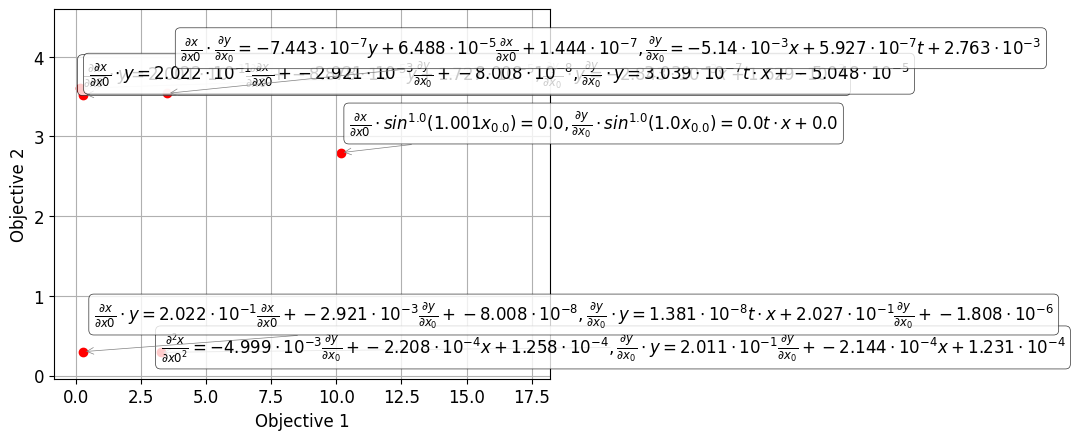


System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e2ce050>, <epde.structure.main_structures.SoEq object at 0x32e5f9510>, <epde.structure.main_structures.SoEq object at 0x32e5ce6d0>, <epde.structure.main_structures.SoEq object at 0x32e4c14d0>, <epde.structure.main_structures.SoEq object at 0x32e1bb690>, <epde.structure.main_structures.SoEq object at 0x32de9abd0>]
Saved: output/robot_31/system_43.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e3b1a50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e3b1a50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1

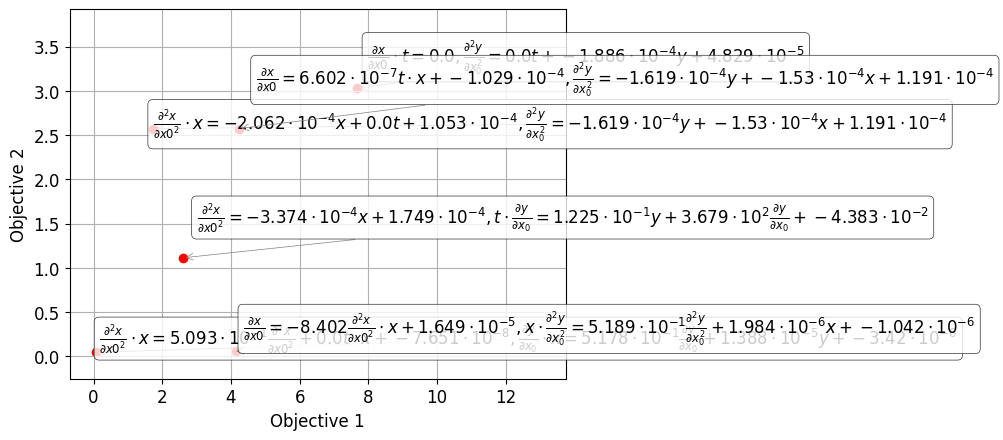


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e59a390>, <epde.structure.main_structures.SoEq object at 0x32df15090>, <epde.structure.main_structures.SoEq object at 0x32def3790>, <epde.structure.main_structures.SoEq object at 0x32df1fe10>, <epde.structure.main_structures.SoEq object at 0x32e48c750>, <epde.structure.main_structures.SoEq object at 0x32e45ed10>]
Saved: output/robot_31/system_44.csv































 Processing robot 32 with 4 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32de4be10>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32de4be10>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined 

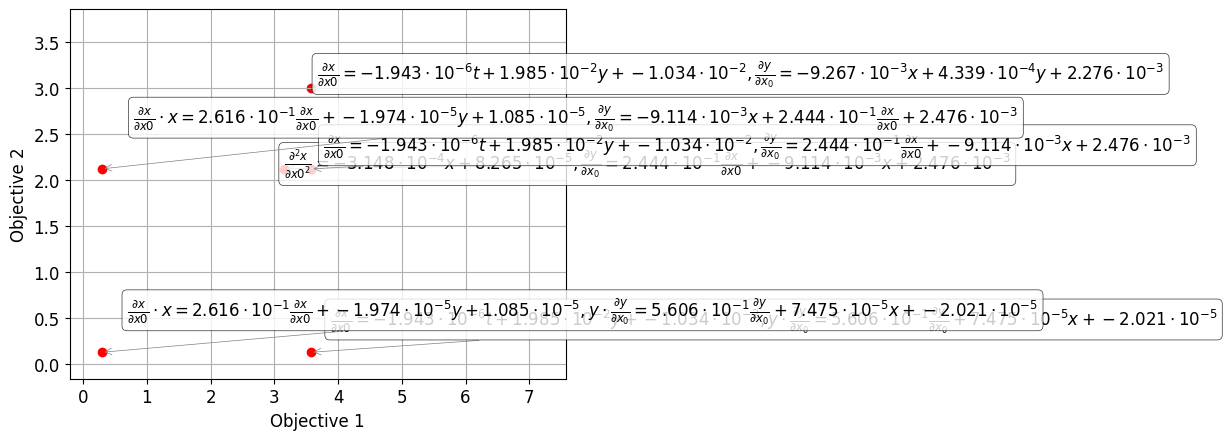


System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32de4d910>, <epde.structure.main_structures.SoEq object at 0x32de60f90>, <epde.structure.main_structures.SoEq object at 0x32e1a9ed0>, <epde.structure.main_structures.SoEq object at 0x32dfaba10>, <epde.structure.main_structures.SoEq object at 0x32e0f1490>, <epde.structure.main_structures.SoEq object at 0x32e051390>]
Saved: output/robot_32/system_41.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32de52a90>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32de52a90>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No

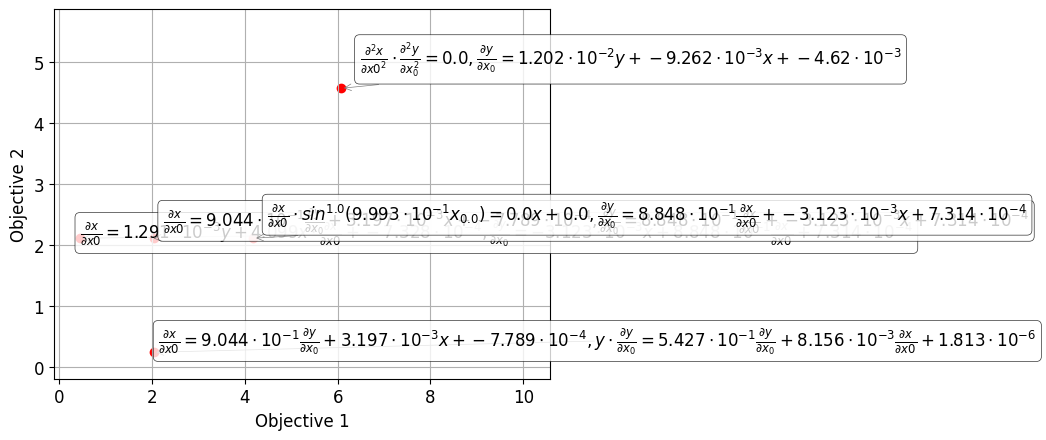


System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e59ee90>, <epde.structure.main_structures.SoEq object at 0x32e52f3d0>, <epde.structure.main_structures.SoEq object at 0x32e29c110>, <epde.structure.main_structures.SoEq object at 0x32e5d78d0>, <epde.structure.main_structures.SoEq object at 0x32e051790>]
EQ 2:
Saved: output/robot_32/system_42.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e29d650>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e29d650>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data 

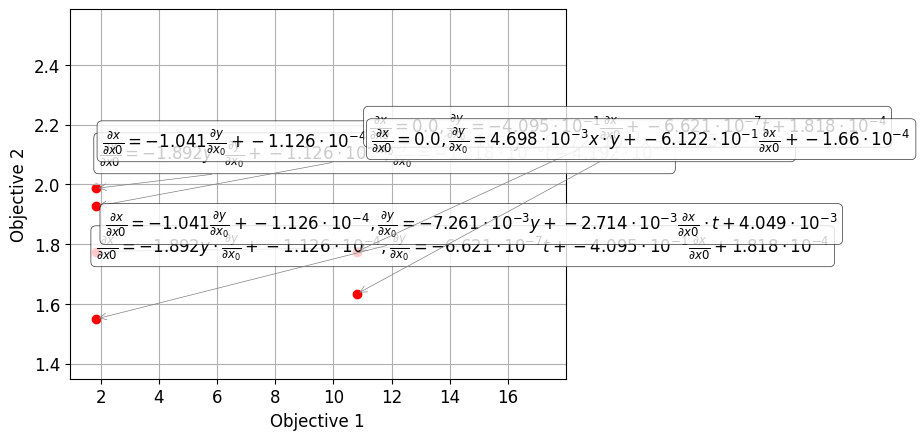


System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e35b790>, <epde.structure.main_structures.SoEq object at 0x32e050f90>, <epde.structure.main_structures.SoEq object at 0x32df909d0>, <epde.structure.main_structures.SoEq object at 0x32dea9210>, <epde.structure.main_structures.SoEq object at 0x32e5afe50>, <epde.structure.main_structures.SoEq object at 0x32e540910>]
Saved: output/robot_32/system_43.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e406750>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e406750>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1

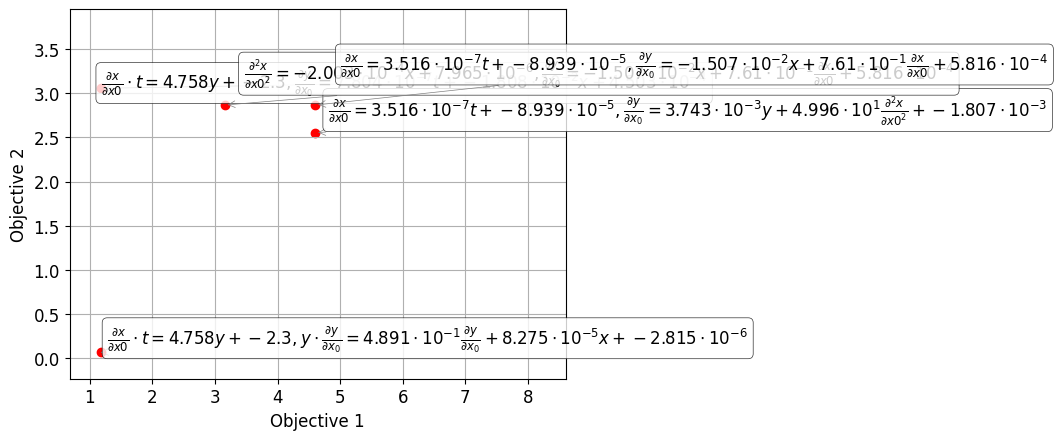


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e35e050>, <epde.structure.main_structures.SoEq object at 0x32e3e5010>, <epde.structure.main_structures.SoEq object at 0x32df58d10>, <epde.structure.main_structures.SoEq object at 0x32e035690>, <epde.structure.main_structures.SoEq object at 0x32e10a890>]
EQ 2:
Saved: output/robot_32/system_44.csv































 Processing robot 34 with 4 parts...
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32de5c710>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32de5c710>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contai

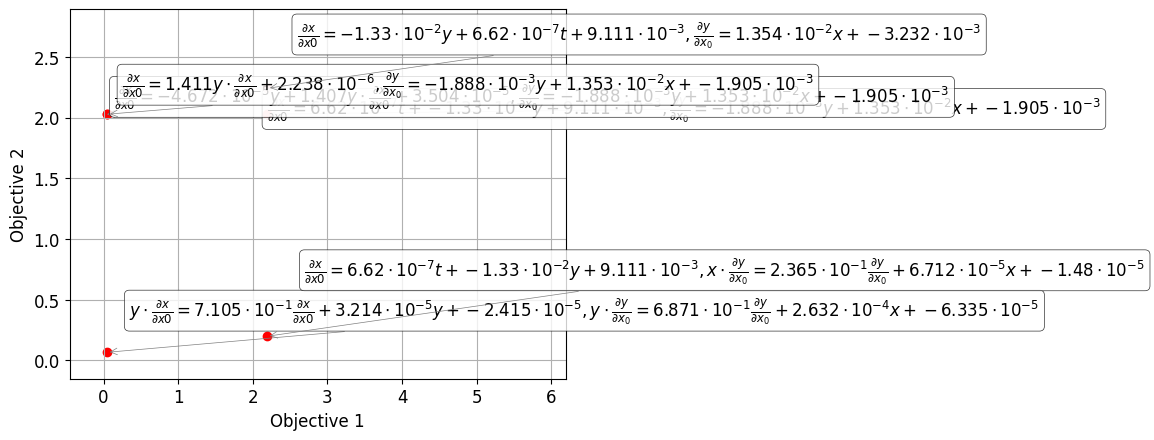


System of DE 1 (startpoint 0-686):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32df68210>, <epde.structure.main_structures.SoEq object at 0x32de4c310>, <epde.structure.main_structures.SoEq object at 0x32deafd50>, <epde.structure.main_structures.SoEq object at 0x32dff1310>, <epde.structure.main_structures.SoEq object at 0x32e140a50>, <epde.structure.main_structures.SoEq object at 0x32de49a10>]
Saved: output/robot_34/system_41.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e1fef50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e1fef50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No

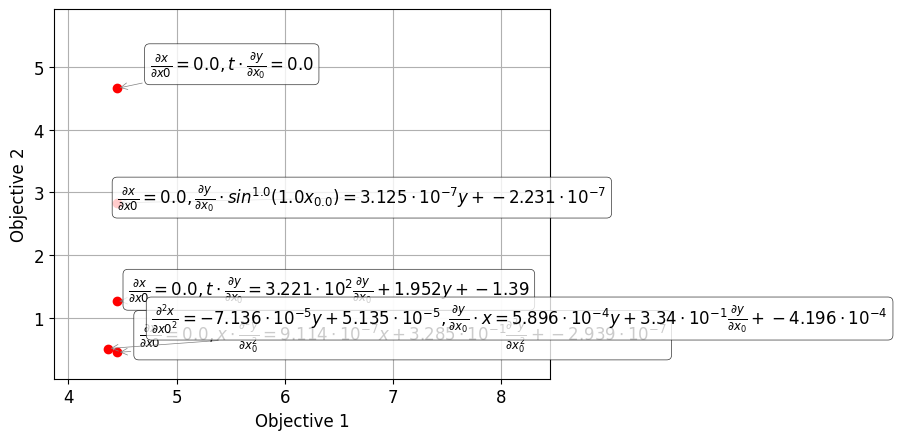


System of DE 2 (startpoint 687-1373):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32df8c290>, <epde.structure.main_structures.SoEq object at 0x32e236010>, <epde.structure.main_structures.SoEq object at 0x32e218510>, <epde.structure.main_structures.SoEq object at 0x32e347350>, <epde.structure.main_structures.SoEq object at 0x32e018390>]
EQ 2:
Saved: output/robot_34/system_42.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e261610>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x32e261610>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
687
initial_shape (687,) derivs_tensor.shape (687, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1]
No sin data in cache!
No cos data in cache!
No t data 

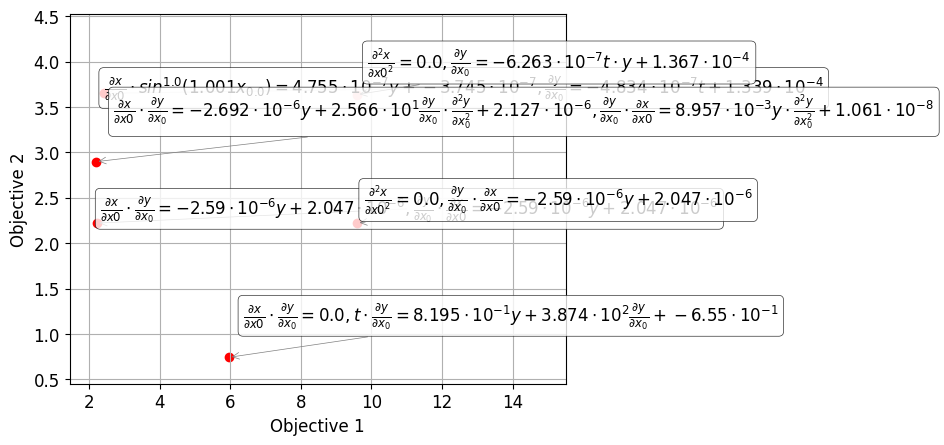


System of DE 3 (startpoint 1374-2060):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e2becd0>, <epde.structure.main_structures.SoEq object at 0x32e5b9090>, <epde.structure.main_structures.SoEq object at 0x32e24ed50>, <epde.structure.main_structures.SoEq object at 0x32e313410>, <epde.structure.main_structures.SoEq object at 0x174f65490>, <epde.structure.main_structures.SoEq object at 0x32e240c10>]
Saved: output/robot_34/system_43.csv
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15fb87b50>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x15fb87b50>
trig_token_params: VALUES = (0, 0)
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 3
Deriv orders after definition [[0], [0, 0]]
689
initial_shape (689,) derivs_tensor.shape (689, 2)
Size of linked labels is 6
The cardinality of defined token pool is [1 2 1 2 2 1]
Among them, the pool contains [1 2 1 2 1

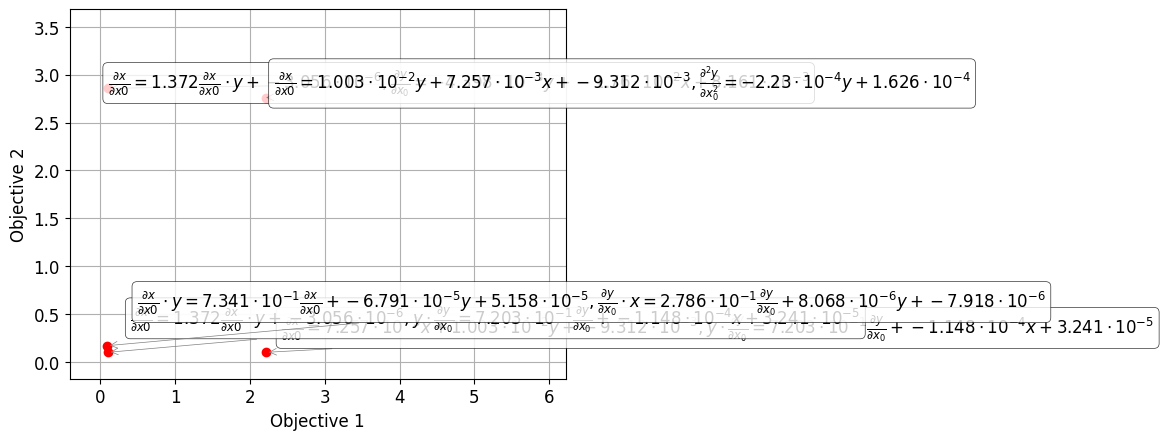


System of DE 4 (startpoint 2061-2749):
EQ 1:
[<epde.structure.main_structures.SoEq object at 0x32e07cc90>, <epde.structure.main_structures.SoEq object at 0x174f2f3d0>, <epde.structure.main_structures.SoEq object at 0x32df44d10>, <epde.structure.main_structures.SoEq object at 0x32df454d0>, <epde.structure.main_structures.SoEq object at 0x32e5fc250>]
EQ 2:
Saved: output/robot_34/system_44.csv


In [16]:
# ====================
# --- MAIN PIPELINE ---
# ====================
def process_robot(object_id, normalized_coord_data, num_parts=1, output_dir=Path("output")):
    """PROCESS ONE ROBOT AND SPLIT INTO PARTS"""
    print(f"\n Processing robot {object_id} with {num_parts} parts...")

    # === Create directories ===
    robot_dir = output_dir / f"robot_{object_id}"
    robot_dir.mkdir(parents=True, exist_ok=True)

    points = np.array(normalized_coord_data[object_id])
    cut_number = min(2750, len(points))
    cut_points = points[:cut_number]

    part_size = cut_number // num_parts
    boundaries = [i * part_size for i in range(num_parts)] + [cut_number]

    for part_idx in range(num_parts):
        start_idx = boundaries[part_idx]
        end_idx = boundaries[part_idx + 1]
        part_points = cut_points[start_idx:end_idx]

        t_data = np.arange(len(part_points))
        x_data, y_data = part_points[:, 0], part_points[:, 1]

        systems_equations = []
        systems_tables = []
        equation_processor = EquationProcessor()
        variable_names = ['x', 'y']

        epde_search_obj_system = EpdeSearch(
            use_solver=False,
            boundary=4,
            coordinate_tensors=[t_data]
        )

        epde_search_obj_system.set_moeadd_params(
            population_size=6,
            training_epochs=50
        )
        
        epde_search_obj_system.set_preprocessor(
            default_preprocessor_type='poly',
            preprocessor_kwargs={'use_smoothing': True,
                                    'sigma': 50}
        )
        
        equation_system = EquationDiscoverer([x_data, y_data])

        part_equations = equation_system.discover_system_equation(
            epde_search_obj_system, additional_tokens=[], dimensionality=0
        )
        
        equation_per_level = [
            [[str(eq) for eq in solution.vals] for solution in level] 
            for level in part_equations
        ]
        print(equation_per_level)

        values_per_level = [
        [solution.obj_fun for solution in level]
                            for level in part_equations]
        for level_idx, level in enumerate(values_per_level):
            print(f"Level {level_idx}:")
            for sol_idx, obj_values in enumerate(level):
                print(f"Solution {sol_idx}: {obj_values}")


        # Выводим для проверки
        for level_idx, level in enumerate(equation_per_level):
            print(f"Level {level_idx}:")
            for sol_idx, eq_list in enumerate(level):
                print(f"  Solution {sol_idx}:")
                for eq_str in eq_list:
                    print(f"    {eq_str}")


        fig = plt.figure() 
        epde_search_obj_system.visualize_solutions(dimensions=[0,1])
        plt.show()


        systems_equations.append(part_equations)

        # PREPROCESSING
        table_main = [{i: [{}, {}]} for i in variable_names]
        k = 0

        vals_flat = []
        for elem in part_equations:
            vals_flat.extend(elem)

        table_main, k = equation_processor.object_table(
            [vals_flat], variable_names, table_main, k, ''
        )
        systems_tables.append(table_main)

        print(f"\nSystem of DE {part_idx + 1} (startpoint {start_idx}-{end_idx - 1}):")
        for i, eq in enumerate(part_equations):
            print(f"EQ {i + 1}:")
            print(eq)

        # SAVE TABLE

        frame_main = equation_processor.preprocessing_table(variable_names, table_main, k)
        output_path = robot_dir / f"system_{num_parts}{part_idx + 1}.csv"
        frame_main.to_csv(output_path, sep=',', encoding='utf-8')
        print(f"Saved: {output_path}")



# ==========================
# --- DISTANCE CALCULATOR ---
# ==========================
def find_closest_robots(normalized_coord_data, target_id, n_closest=2):
    """FIND NEAREST ROBOTS TO TARGET"""
    target_coord = normalized_coord_data[target_id][0]
    distances = {
        rid: np.linalg.norm(np.array(coords[0]) - target_coord)
        for rid, coords in normalized_coord_data.items() if rid != target_id
    }
    closest = sorted(distances, key=distances.get)[:n_closest]
    print(f"\n Closest to {target_id}: {closest}")
    return closest


# =====================
# --- MAIN FUNCTION ---
# =====================
def main(target_robot=78, num_parts=2, n_closest=2):
    with open('data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle', 'rb') as file:
        raw_data = pickle.load(file)

    processor = DataProcessor(raw_data)
    processor.extract_data()
    normalized_coord_data = processor.normalize_all_coordinates()
    robots_to_process = [target_robot]
    if n_closest>0:
    # Найти ближайших роботов
        closest = find_closest_robots(normalized_coord_data, target_robot, n_closest)
        robots_to_process += closest

    output_dir = Path("output")
    for rid in robots_to_process:
        process_robot(rid, normalized_coord_data, num_parts=num_parts, output_dir=output_dir)


if __name__ == "__main__":
    for i in [78, 79,  83, 31, 32 , 34]:
        main(target_robot=i, num_parts=4, n_closest=0)


In [137]:
import pickle
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from scipy.ndimage import gaussian_filter1d

FILE_PATH = 'data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle'
CUT_NUMBER = 2750
SIGMA = 50
TARGET_ID = 78
NUM_CLOSEST = 2

# === 1. Загрузка данных ===
with open(FILE_PATH, 'rb') as f:
    data = pickle.load(f)

processor = DataProcessor(data)
coord_data = processor.extract_data()
normalized_coord_data = processor.normalize_all_coordinates()

# === 5. Определение ближайших роботов ===
target_start = normalized_coord_data[TARGET_ID][0]
distances = {
    rid: np.linalg.norm(np.array(coords[0]) - target_start)
    for rid, coords in normalized_coord_data.items() if rid != TARGET_ID
}
closest_ids = sorted(distances, key=distances.get)[:NUM_CLOSEST]
print(f"Ближайшие к роботу {TARGET_ID}: {closest_ids}")

# === 6. Построение траекторий ===
fig = go.Figure()
colors = ['DarkOrange', 'DarkBlue', 'DarkRed', 'YellowGreen', 'Plum']

selected_ids = [TARGET_ID] + closest_ids
for i, rid in enumerate(selected_ids):
    coords = normalized_coord_data[rid][:CUT_NUMBER]
    x, y = coords[:, 0], coords[:, 1]
    color = colors[i % len(colors)]
    print(gaussian_filter1d(x, sigma=SIGMA))
    continue
    # Линия траектории
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', line=dict(color=color, width=1),
                             name=f'Trajectory {rid}'))

    # Начальная точка
    fig.add_trace(go.Scatter(x=[x[0]], y=[y[0]], mode='markers',
                             marker=dict(color=color, symbol='circle', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'Start {rid}'))

    # Конечная точка
    fig.add_trace(go.Scatter(x=[x[-1]], y=[y[-1]], mode='markers',
                             marker=dict(color=color, symbol='x', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'End {rid}'))

fig.update_layout(
    legend=dict(
        x=1.3,           # смещение по горизонтали (отрицательное = слева от графика)
        y=0.8,            # центрирование по вертикали
        xanchor="right",  # якорь легенды (правый край легенды совпадает с x)
        yanchor="middle", # центр по y
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='Black',
        borderwidth=0.5
    ),
    font_family="Inter Medium",
    plot_bgcolor='white',
    showlegend=True,
    margin=dict(l=50, r=10, t=10, b=10),  # увеличиваем левый отступ под легенду
    height=500,
    width=900
)

fig.update_xaxes(
    showgrid=False,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
)
fig.update_yaxes(
    showgrid=False,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey'
)

fig.update_xaxes(title_text="X Coordinate")
fig.update_yaxes(title_text="Y Coordinate")
fig.show()
fig.write_html("Trajectories.html")

# === 7. Дополнительно: координаты X(t), Y(t) с сглаживанием ===
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.02)

for i, rid in enumerate(selected_ids):
    coords = normalized_coord_data[rid][:CUT_NUMBER]
    t = np.arange(len(coords))
    x, y = coords[:, 0], coords[:, 1]
    color = colors[i % len(colors)]
    
    continue
    # X(t)
    fig.add_trace(go.Scatter(x=t, y=x, mode='lines', line=dict(color=color, width=1),
                             name=f'X, robot {rid}'), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(x, sigma=SIGMA),
                             mode='lines', line=dict(color=color, width=3),
                             name=f'Smooth X, robot {rid}'), row=1, col=1)

    # Y(t)
    fig.add_trace(go.Scatter(x=t, y=y, mode='lines', line=dict(color=color, width=1),
                             showlegend=False), row=2, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(y, sigma=SIGMA),
                             mode='lines', line=dict(color=color, width=3),
                             showlegend=False), row=2, col=1)

fig.update_layout(
    legend=dict(
        x=1.3,           # смещение по горизонтали (отрицательное = слева от графика)
        y=0.85,            # центрирование по вертикали
        xanchor="right",  # якорь легенды (правый край легенды совпадает с x)
        yanchor="middle", # центр по y
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='Black',
        borderwidth=0.5
    ),
    font_family="Inter Medium",
    plot_bgcolor='white',
    showlegend=True,
    margin=dict(l=50, r=10, t=10, b=10),  # увеличиваем левый отступ под легенду
    height=500,
    width=900
)
fig.update_xaxes(showgrid=False, mirror=True, ticks='outside', showline=True, linecolor='black', gridcolor='lightgrey', dtick=250)
fig.update_yaxes(showgrid=False, mirror=True, ticks='outside', showline=True, linecolor='black', gridcolor='lightgrey')
fig.update_xaxes(title_text="Time", row=2, col=1)
fig.update_yaxes(title_text="X Coordinate",dtick=200, row=1, col=1)
fig.update_yaxes(title_text="Y Coordinate", dtick=200, row=2, col=1)
fig.show()
fig.write_html("XY_vs_time.html")
































Ближайшие к роботу 78: [28, 74]
[0.85124182 0.85124042 0.85123764 ... 0.67708157 0.67708112 0.6770809 ]
[0.9865432  0.98654276 0.98654189 ... 0.97691133 0.97690993 0.97690923]
[0.89908895 0.89909098 0.89909504 ... 0.82112191 0.82111048 0.82110476]


In [ ]:
import pickle
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from scipy.ndimage import gaussian_filter1d

FILE_PATH = 'data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle'
CUT_NUMBER = 2750
SIGMA = 50
TARGET_ID = 78
NUM_CLOSEST = 2

# === 1. Загрузка данных ===
with open(FILE_PATH, 'rb') as f:
    data = pickle.load(f)

processor = DataProcessor(data)
coord_data = processor.extract_data()
normalized_coord_data = processor.normalize_all_coordinates()

# === 5. Определение ближайших роботов ===
target_start = normalized_coord_data[TARGET_ID][0]
distances = {
    rid: np.linalg.norm(np.array(coords[0]) - target_start)
    for rid, coords in normalized_coord_data.items() if rid != TARGET_ID
}
closest_ids = sorted(distances, key=distances.get)[:NUM_CLOSEST]
print(f"Ближайшие к роботу {TARGET_ID}: {closest_ids}")

# === 6. Построение траекторий ===
fig = go.Figure()
colors = ['DarkOrange', 'DarkBlue', 'DarkRed', 'YellowGreen', 'Plum']

selected_ids = [TARGET_ID] + closest_ids
for i, rid in enumerate(selected_ids):
    coords = normalized_coord_data[rid][:CUT_NUMBER]
    x, y = coords[:, 0], coords[:, 1]
    color = colors[i % len(colors)]

    # Линия траектории
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', line=dict(color=color, width=1),
                             name=f'Trajectory {rid}'))

    # Начальная точка
    fig.add_trace(go.Scatter(x=[x[0]], y=[y[0]], mode='markers',
                             marker=dict(color=color, symbol='circle', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'Start {rid}'))

    # Конечная точка
    fig.add_trace(go.Scatter(x=[x[-1]], y=[y[-1]], mode='markers',
                             marker=dict(color=color, symbol='x', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'End {rid}'))

fig.update_layout(
    legend=dict(
        x=1.3,           # смещение по горизонтали (отрицательное = слева от графика)
        y=0.8,            # центрирование по вертикали
        xanchor="right",  # якорь легенды (правый край легенды совпадает с x)
        yanchor="middle", # центр по y
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='Black',
        borderwidth=0.5
    ),
    font_family="Inter Medium",
    plot_bgcolor='white',
    showlegend=True,
    margin=dict(l=50, r=10, t=10, b=10),  # увеличиваем левый отступ под легенду
    height=500,
    width=900
)

fig.update_xaxes(
    showgrid=False,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
)
fig.update_yaxes(
    showgrid=False,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey'
)

fig.update_xaxes(title_text="X Coordinate")
fig.update_yaxes(title_text="Y Coordinate")
fig.show()
fig.write_html("Trajectories.html")

# === 7. Дополнительно: координаты X(t), Y(t) с сглаживанием ===
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.02)

for i, rid in enumerate(selected_ids):
    coords = normalized_coord_data[rid][:CUT_NUMBER]
    t = np.arange(len(coords))
    x, y = coords[:, 0], coords[:, 1]
    color = colors[i % len(colors)]

    # X(t)
    fig.add_trace(go.Scatter(x=t, y=x, mode='lines', line=dict(color=color, width=1),
                             name=f'X, robot {rid}'), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(x, sigma=SIGMA),
                             mode='lines', line=dict(color=color, width=3),
                             name=f'Smooth X, robot {rid}'), row=1, col=1)

    # Y(t)
    fig.add_trace(go.Scatter(x=t, y=y, mode='lines', line=dict(color=color, width=1),
                             showlegend=False), row=2, col=1)
    fig.add_trace(go.Scatter(x=t, y=gaussian_filter1d(y, sigma=SIGMA),
                             mode='lines', line=dict(color=color, width=3),
                             showlegend=False), row=2, col=1)

fig.update_layout(
    legend=dict(
        x=1.3,           # смещение по горизонтали (отрицательное = слева от графика)
        y=0.85,            # центрирование по вертикали
        xanchor="right",  # якорь легенды (правый край легенды совпадает с x)
        yanchor="middle", # центр по y
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='Black',
        borderwidth=0.5
    ),
    font_family="Inter Medium",
    plot_bgcolor='white',
    showlegend=True,
    margin=dict(l=50, r=10, t=10, b=10),  # увеличиваем левый отступ под легенду
    height=500,
    width=900
)
fig.update_xaxes(showgrid=False, mirror=True, ticks='outside', showline=True, linecolor='black', gridcolor='lightgrey', dtick=250)
fig.update_yaxes(showgrid=False, mirror=True, ticks='outside', showline=True, linecolor='black', gridcolor='lightgrey')
fig.update_xaxes(title_text="Time", row=2, col=1)
fig.update_yaxes(title_text="X Coordinate",dtick=200, row=1, col=1)
fig.update_yaxes(title_text="Y Coordinate", dtick=200, row=2, col=1)
fig.show()
fig.write_html("XY_vs_time.html")
